# Choosing Dataset Parameters & `XGBoost` Model Hyperparameters

## Purpose: 
{TODO}

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

%load_ext autoreload 
%autoreload 2

import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.max_colwidth', 10000000)

import importlib
parameter_analyzer = getattr(
    importlib.import_module("dataset_and_model_parameter_chooser"), 
    "DatasetAndModelParameterAnalyzer"
)


<h1 style="color: teal; font-weight: bold; font-size: 48px;">Load WandB Data & Check Data</h1>

In [2]:
analyzer = parameter_analyzer()

2025-04-08 11:03:46.861 | WARNING  | dataset_and_model_parameter_chooser:retrieve_wandb_summary_tables:39 - REMINDER: removing early_stopping_rounds outside of 100
2025-04-08 11:03:46.864 | INFO     | dataset_and_model_parameter_chooser:retrieve_wandb_summary_tables:45 - dataset summary table contains 120 rows
2025-04-08 11:03:46.865 | INFO     | dataset_and_model_parameter_chooser:retrieve_wandb_summary_tables:45 - model summary table contains 1980 rows
2025-04-08 11:03:46.866 | SUCCESS  | dataset_and_model_parameter_chooser:retrieve_wandb_summary_tables:47 - FROM CACHE: Retrieved WandB summary tables


In [4]:
analyzer.run_summary_table_assertions()

2025-04-08 11:03:47.052 | INFO     | dataset_and_model_parameter_chooser:run_summary_table_assertions:93 - Running assertions on summary tables
2025-04-08 11:03:47.055 | INFO     | dataset_and_model_parameter_chooser:run_summary_table_assertions:96 - Running assertions for dataset summary table
2025-04-08 11:03:47.063 | INFO     | dataset_and_model_parameter_chooser:run_summary_table_assertions:96 - Running assertions for model summary table
2025-04-08 11:03:47.131 | SUCCESS  | dataset_and_model_parameter_chooser:run_summary_table_assertions:123 - All assertions passed


In [5]:
for type in analyzer.sweep_results: 
    type
    analyzer.sweep_results[type].head()

'dataset'

,run_id,run_name,state,sweep_name,sweep_id,model.name,dataset.name,model.n_jobs,training.seed,model.max_depth,model.reg_alpha,model.subsample,dataset.cell_line,model.eval_metric,model.n_estimators,training.criterion,model.learning_rate,training.batch_size,training.wandb.track,dataset.target_fields,training.wandb.entity,dataset.min_read_count,training.profile.plots,training.wandb.project,model.enable_categorical,training.profile.metrics,training.wandb.save_code,dataset.three_exon_combos,training.wandb.save_model,training.wandb.save_plots,training.data_split.method,model.early_stopping_rounds,training.data_split.test_set,training.data_split.train_set,training.wandb.save_artifacts,training.data_split.validate_set,dataset.features.binding_matrix.window,dataset.features.binding_matrix.exp_log,dataset.features.binding_matrix.flatten,dataset.features.binding_matrix.exp_norm,dataset.features.binding_matrix.binding_format,runtime.avg_nodes_per_tree,test_loss,test_mean_absolute_error,test_r2_score,test_rmse,train_loss,train_mean_absolute_error,train_r2_score,train_rmse,val_loss,val_mean_absolute_error,val_r2_score,val_rmse
0,1o95bl4u,glamorous-sweep-6,finished,ayans_model_params_yogi_dataset_sweep,11gitmno,XGBRegressor,RBPSEDataset,-1,42,7,0.3,1,K562,"['rmse', 'logloss']",20000,mean_squared_error,0.1,1024,True,['target_psi'],platiglab,320,[],yogi-dataset-sweep-feb-2025,False,"['r2_score', 'mean_absolute_error', 'rmse']",False,all,False,False,set_defs,100,"['chr2', 'chr8', 'chr12', 'chr16', 'chr20']","['chr1', 'chr3', 'chr5', 'chr7', 'chr9', 'chr11', 'chr13', 'chr15', 'chr17', 'chr19', 'chr21']",False,"['chr4', 'chr6', 'chr10', 'chr14', 'chr18', 'chr22']",50,True,False,getmm,binary,69.500000,0.000166,0.1645,0.2155,0.2772,0.000047,0.1331,0.3402,0.2330,0.000181,0.1529,0.2067,0.2604
1,5j9ipstu,brisk-sweep-1,finished,ayans_model_params_yogi_dataset_sweep,11gitmno,XGBRegressor,RBPSEDataset,-1,42,7,0.3,1,K562,"['rmse', 'logloss']",20000,mean_squared_error,0.1,1024,True,['target_psi'],platiglab,0,[],yogi-dataset-sweep-feb-2025,False,"['r2_score', 'mean_absolute_error', 'rmse']",False,all,False,False,set_defs,100,"['chr2', 'chr8', 'chr12', 'chr16', 'chr20']","['chr1', 'chr3', 'chr5', 'chr7', 'chr9', 'chr11', 'chr13', 'chr15', 'chr17', 'chr19', 'chr21']",False,"['chr4', 'chr6', 'chr10', 'chr14', 'chr18', 'chr22']",50,True,False,getmm,binary,81.634328,0.000055,0.2571,0.1746,0.3328,0.000021,0.2372,0.2062,0.3124,0.000069,0.2484,0.1676,0.3229
2,9kh7spri,sandy-sweep-4,finished,ayans_model_params_yogi_dataset_sweep,11gitmno,XGBRegressor,RBPSEDataset,-1,42,7,0.3,1,K562,"['rmse', 'logloss']",20000,mean_squared_error,0.1,1024,True,['target_psi'],platiglab,80,[],yogi-dataset-sweep-feb-2025,False,"['r2_score', 'mean_absolute_error', 'rmse']",False,all,False,False,set_defs,100,"['chr2', 'chr8', 'chr12', 'chr16', 'chr20']","['chr1', 'chr3', 'chr5', 'chr7', 'chr9', 'chr11', 'chr13', 'chr15', 'chr17', 'chr19', 'chr21']",False,"['chr4', 'chr6', 'chr10', 'chr14', 'chr18', 'chr22']",50,True,False,getmm,binary,76.023077,0.000075,0.2013,0.1953,0.3001,0.000026,0.1799,0.2428,0.2745,0.000092,0.1920,0.1891,0.2883
3,ainnw5al,iconic-sweep-3,finished,ayans_model_params_yogi_dataset_sweep,11gitmno,XGBRegressor,RBPSEDataset,-1,42,7,0.3,1,K562,"['rmse', 'logloss']",20000,mean_squared_error,0.1,1024,True,['target_psi'],platiglab,40,[],yogi-dataset-sweep-feb-2025,False,"['r2_score', 'mean_absolute_error', 'rmse']",False,all,False,False,set_defs,100,"['chr2', 'chr8', 'chr12', 'chr16', 'chr20']","['chr1', 'chr3', 'chr5', 'chr7', 'chr9', 'chr11', 'chr13', 'chr15', 'chr17', 'chr19', 'chr21']",False,"['chr4', 'chr6', 'chr10', 'chr14', 'chr18', 'chr22']",50,True,False,getmm,binary,76.436090,0.000064,0.2202,0.1897,0.3120,0.000023,0.1989,0.2338,0.2877,0.000080,0.2103,0.1848,0.3003
4,nhhpps7z,clean-sweep-7,finished,ayans_model_params_yogi_dataset_sweep,11gitmno,XGBRegressor,RBPSEDataset,-1,42,7,0.3,1,K562,"['rmse', 'logloss']",20000,mean_squared_error,0.1,1024,True,['target_psi'],platig

'model'

,run_id,run_name,state,sweep_name,sweep_id,model.name,model.gamma,dataset.name,model.n_jobs,training.seed,dataset.window,model.max_depth,model.objective,model.reg_alpha,model.subsample,model.reg_lambda,dataset.cell_line,model.eval_metric,platiglib_project,model.n_estimators,training.criterion,model.learning_rate,training.batch_size,training.wandb.track,dataset.target_fields,training.wandb.entity,dataset.min_read_count,model.colsample_bytree,model.min_child_weight,training.profile.plots,training.wandb.project,dataset.fold_filter.seed,dataset.fold_filter.side,training.profile.metrics,training.wandb.save_code,dataset.three_exon_combos,training.wandb.save_model,training.wandb.save_plots,training.data_split.method,model.early_stopping_rounds,dataset.fold_filter.num_folds,training.data_split.num_folds,training.wandb.save_artifacts,dataset.fold_filter.fold_index,dataset.fold_filter.group_column,training.data_split.group_column,training.data_split.validate_frac_of_train,dataset.features.binding_matrix.in_silico_kd,dataset.features.binding_matrix.binding_format,holdout_fold_mean_mean_absolute_error,holdout_fold_mean_r2_score,holdout_fold_mean_rmse,holdout_loss,holdout_mean_absolute_error,holdout_r2_score,holdout_rmse
630,9eb0q1ls,splendid-sweep-631,finished,1:early_stopping_rounds-learning_rate-max_depth,ft20ki6n,XGBRegressor,0.0,RBPSEDataset,-1,100,100,3,reg:logistic,0.0,1.0,1.0,K562,"['rmse', 'logloss']",rbpse,100000,mean_squared_error,0.01,1024,True,['target_psi'],platiglab,40,1.0,1,"['fancy_scatter', 'cumul_resid_dist', ['wandb_faux_pr_curve', {'thresh': 0.5}], ['wandb_faux_roc_curve', {'thresh': 0.5}]]",yogi-xgbregressor-hyperparameter-sweep-april-2025,17,train,"['r2_score', 'mean_absolute_error', 'rmse']",False,all,False,False,cross_validation,100,5,5,False,1,ensembl_gene_id,ensembl_gene_id,0.1,True,binary,0.1884,0.2789,0.2837,0.08044,0.1883,0.2790,0.2836
631,zoq0lqvf,woven-sweep-632,finished,1:early_stopping_rounds-learning_rate-max_depth,ft20ki6n,XGBRegressor,0.0,RBPSEDataset,-1,200,100,3,reg:logistic,0.0,1.0,1.0,K562,"['rmse', 'logloss']",rbpse,100000,mean_squared_error,0.01,1024,True,['target_psi'],platiglab,40,1.0,1,"['fancy_scatter', 'cumul_resid_dist', ['wandb_faux_pr_curve', {'thresh': 0.5}], ['wandb_faux_roc_curve', {'thresh': 0.5}]]",yogi-xgbregressor-hyperparameter-sweep-april-2025,17,train,"['r2_score', 'mean_absolute_error', 'rmse']",False,all,False,False,cross_validation,100,5,5,False,1,ensembl_gene_id,ensembl_gene_id,0.1,True,binary,0.1881,0.2786,0.2836,0.08046,0.1881,0.2788,0.2837
632,otibvyy0,classic-sweep-633,finished,1:early_stopping_rounds-learning_rate-max_depth,ft20ki6n,XGBRegressor,0.0,RBPSEDataset,-1,300,100,3,reg:logistic,0.0,1.0,1.0,K562,"['rmse', 'logloss']",rbpse,100000,mean_squared_error,0.01,1024,True,['target_psi'],platiglab,40,1.0,1,"['fancy_scatter', 'cumul_resid_dist', ['wandb_faux_pr_curve', {'thresh': 0.5}], ['wandb_faux_roc_curve', {'thresh': 0.5}]]",yogi-xgbregressor-hyperparameter-sweep-april-2025,17,train,"['r2_score', 'mean_absolute_error', 'rmse']",False,all,False,False,cross_validation,100,5,5,False,1,ensembl_gene_id,ensembl_gene_id,0.1,True,binary,0.1879,0.2822,0.2829,0.08006,0.1879,0.2824,0.2830
633,vf4u3vvs,vibrant-sweep-634,finished,1:early_stopping_rounds-learning_rate-max_depth,ft20ki6n,XGBRegressor,0.0,RBPSEDataset,-1,400,100,3,reg:logistic,0.0,1.0,1.0,K562,"['rmse', 'logloss']",rbpse,100000,mean_squared_error,0.01,1024,True,['target_psi'],platiglab,40,1.0,1,"['fancy_scatter', 'cumul_resid_dist', ['wandb_faux_pr_curve', {'thresh': 0.5}], ['wandb_faux_roc_curve', {'thresh': 0.5}]]",yogi-xgbregressor-hyperparameter-sweep-april-2025,17,train,"['r2_score', 'mean_absolute_error', 'rmse']",False,all,False,False,cross_validation,100,5,5,False,1,ensembl_gene_id,ensembl_gene_id,0.1,True,binary,0.1889,0.2786,0.2836,0.08045,0.1889,0.2789,0.2836
634,79xqkbc4,swept-sweep-635,finished,1:early_stopping_rounds-learning_rate-max_depth,ft20ki6n,XGBRegressor,0.0,RBPSEDataset,-1,500,100,3,reg:logisti

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Rank Hyperparameter Choices While Running Sequential Sweeps</h1>

In [6]:
dfs = analyzer.show_top_model_configs_after_averaging_by_seed(all_configs=False)

for key in dfs: 
    key
    dfs[key]

2025-04-08 11:03:51.137 | INFO     | dataset_and_model_parameter_chooser:show_top_model_configs_after_averaging_by_seed:245 - Model sweep shape: (1980, 56)


'1:early_stopping_rounds-learning_rate-max_depth'

,model.early_stopping_rounds,model.learning_rate,model.max_depth,dataset.cell_line,avg_holdout_r2_score
0,100,0.05,3,HepG2,0.289356
1,100,0.05,5,HepG2,0.289100
2,100,0.10,3,HepG2,0.288944
3,100,0.01,3,HepG2,0.288711
4,100,0.15,3,HepG2,0.288689
5,100,0.01,5,HepG2,0.288600
6,100,0.10,5,HepG2,0.288422
7,100,0.05,7,HepG2,0.288000
8,100,0.20,3,HepG2,0.287989
9,100,0.15,5,HepG2,0.287622


'2:min_child_weight-gamma'

,model.min_child_weight,model.gamma,dataset.cell_line,avg_holdout_r2_score
0,30,0.5,HepG2,0.289544
1,30,0.0,HepG2,0.289533
2,1,1.5,HepG2,0.289533
3,5,1.5,HepG2,0.289378
4,1,0.0,HepG2,0.289356
5,10,1.5,HepG2,0.289344
6,10,0.5,HepG2,0.289344
7,1,0.5,HepG2,0.289333
8,30,2.0,HepG2,0.289322
9,30,1.0,HepG2,0.289322


'3:subsample-colsample_bytree'

,model.subsample,model.colsample_bytree,dataset.cell_line,avg_holdout_r2_score
0,1.00,0.75,HepG2,0.289678
1,0.10,1.00,HepG2,0.289667
2,0.25,0.75,HepG2,0.289633
3,1.00,1.00,HepG2,0.289544
4,0.10,0.75,HepG2,0.289400
5,0.75,0.50,HepG2,0.289356
6,0.25,1.00,HepG2,0.289344
7,0.75,0.75,HepG2,0.289267
8,0.50,0.75,HepG2,0.289233
9,0.50,0.50,HepG2,0.289211


'4:reg_alpha-reg_lambda'

,model.reg_alpha,model.reg_lambda,dataset.cell_line,avg_holdout_r2_score
0,1.0,10.0,HepG2,0.290489
1,1.0,0.5,HepG2,0.290444
2,0.5,0.5,HepG2,0.290433
3,0.2,10.0,HepG2,0.290400
4,0.0,0.1,HepG2,0.290389
5,0.8,10.0,HepG2,0.290344
6,0.0,1.0,HepG2,0.290267
7,1.0,5.0,HepG2,0.290244
8,1.0,0.1,HepG2,0.290233
9,0.8,5.0,HepG2,0.290200


<h1 style="color: teal; font-weight: bold; font-size: 48px;">Overall R2 Distributions for Dataset & Model Hyperparameter Sweeps</h1>

In [ ]:
# analyzer.load_aggreated_data_stats()

/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/3_choose_dataset_and_model_parameters/code/dataset_and_model_parameter_chooser.py:334: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='dataset.cell_line', y=y_variable, data=data, palette=['lightblue', 'lightcoral'], linewidth=linewidth, edgecolor='black', size=size)


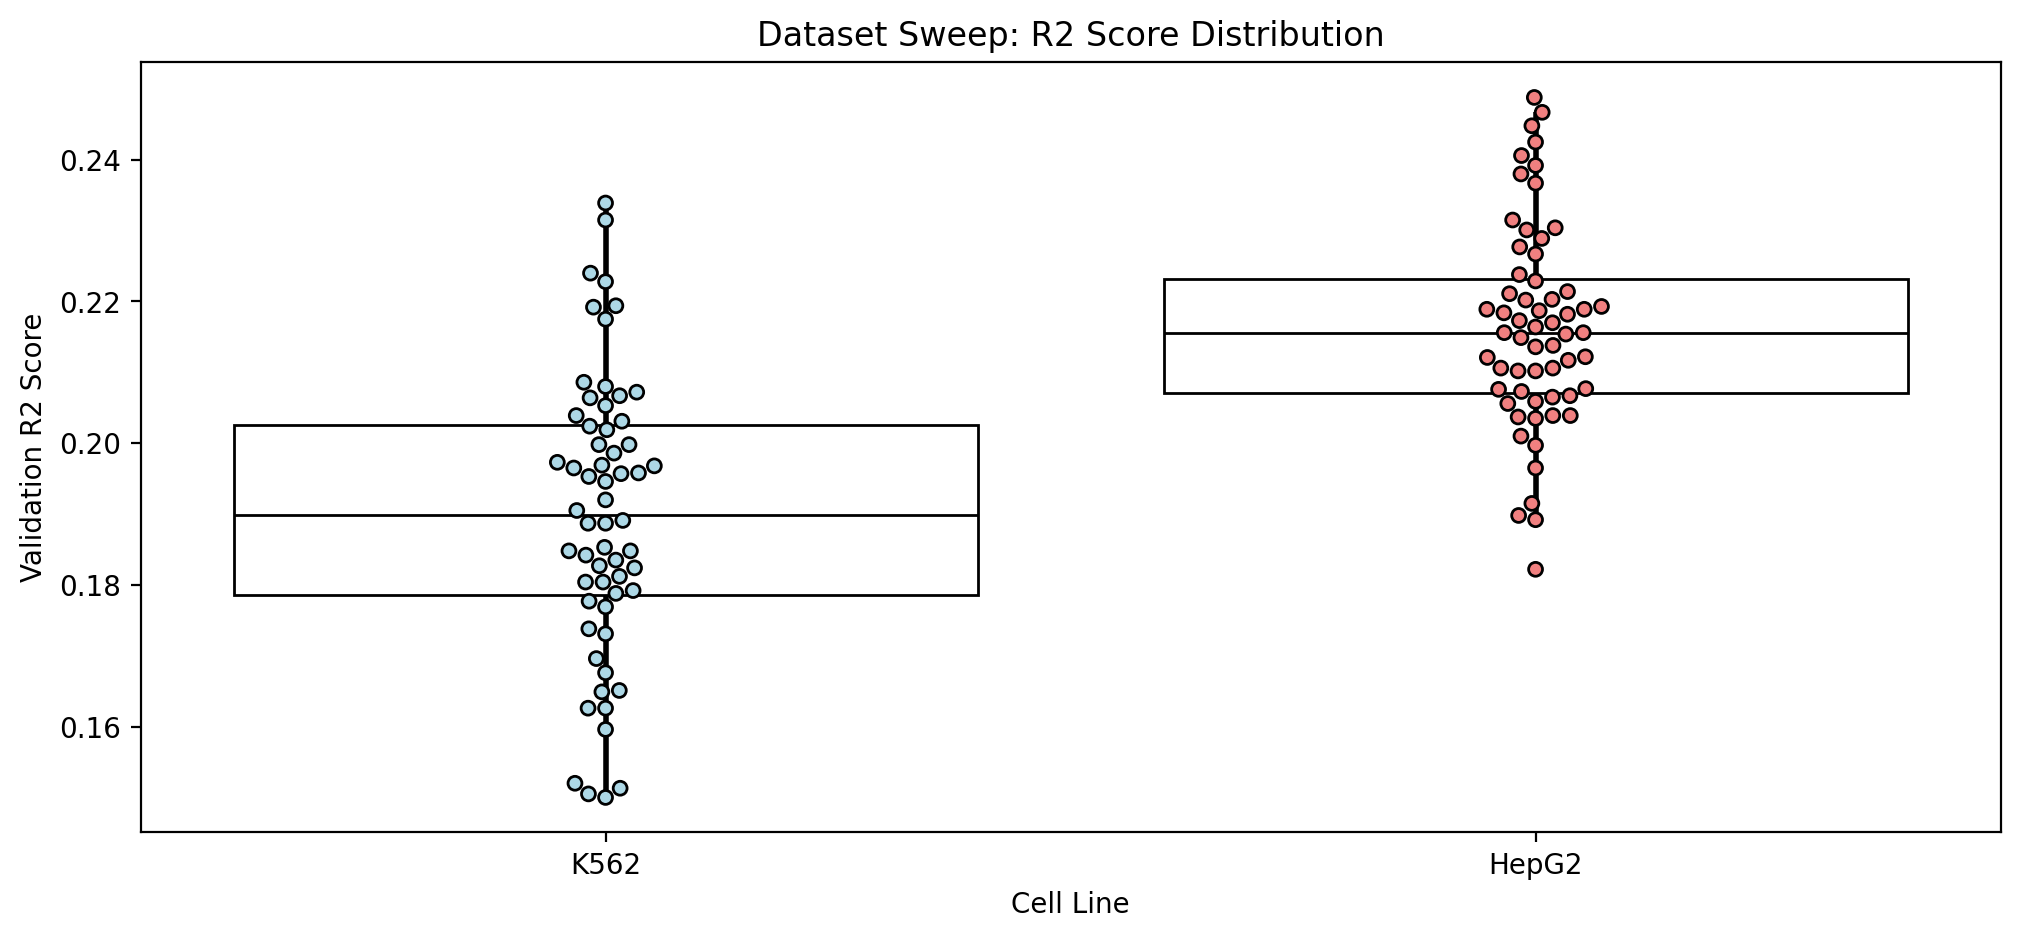

/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/3_choose_dataset_and_model_parameters/code/dataset_and_model_parameter_chooser.py:334: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='dataset.cell_line', y=y_variable, data=data, palette=['lightblue', 'lightcoral'], linewidth=linewidth, edgecolor='black', size=size)


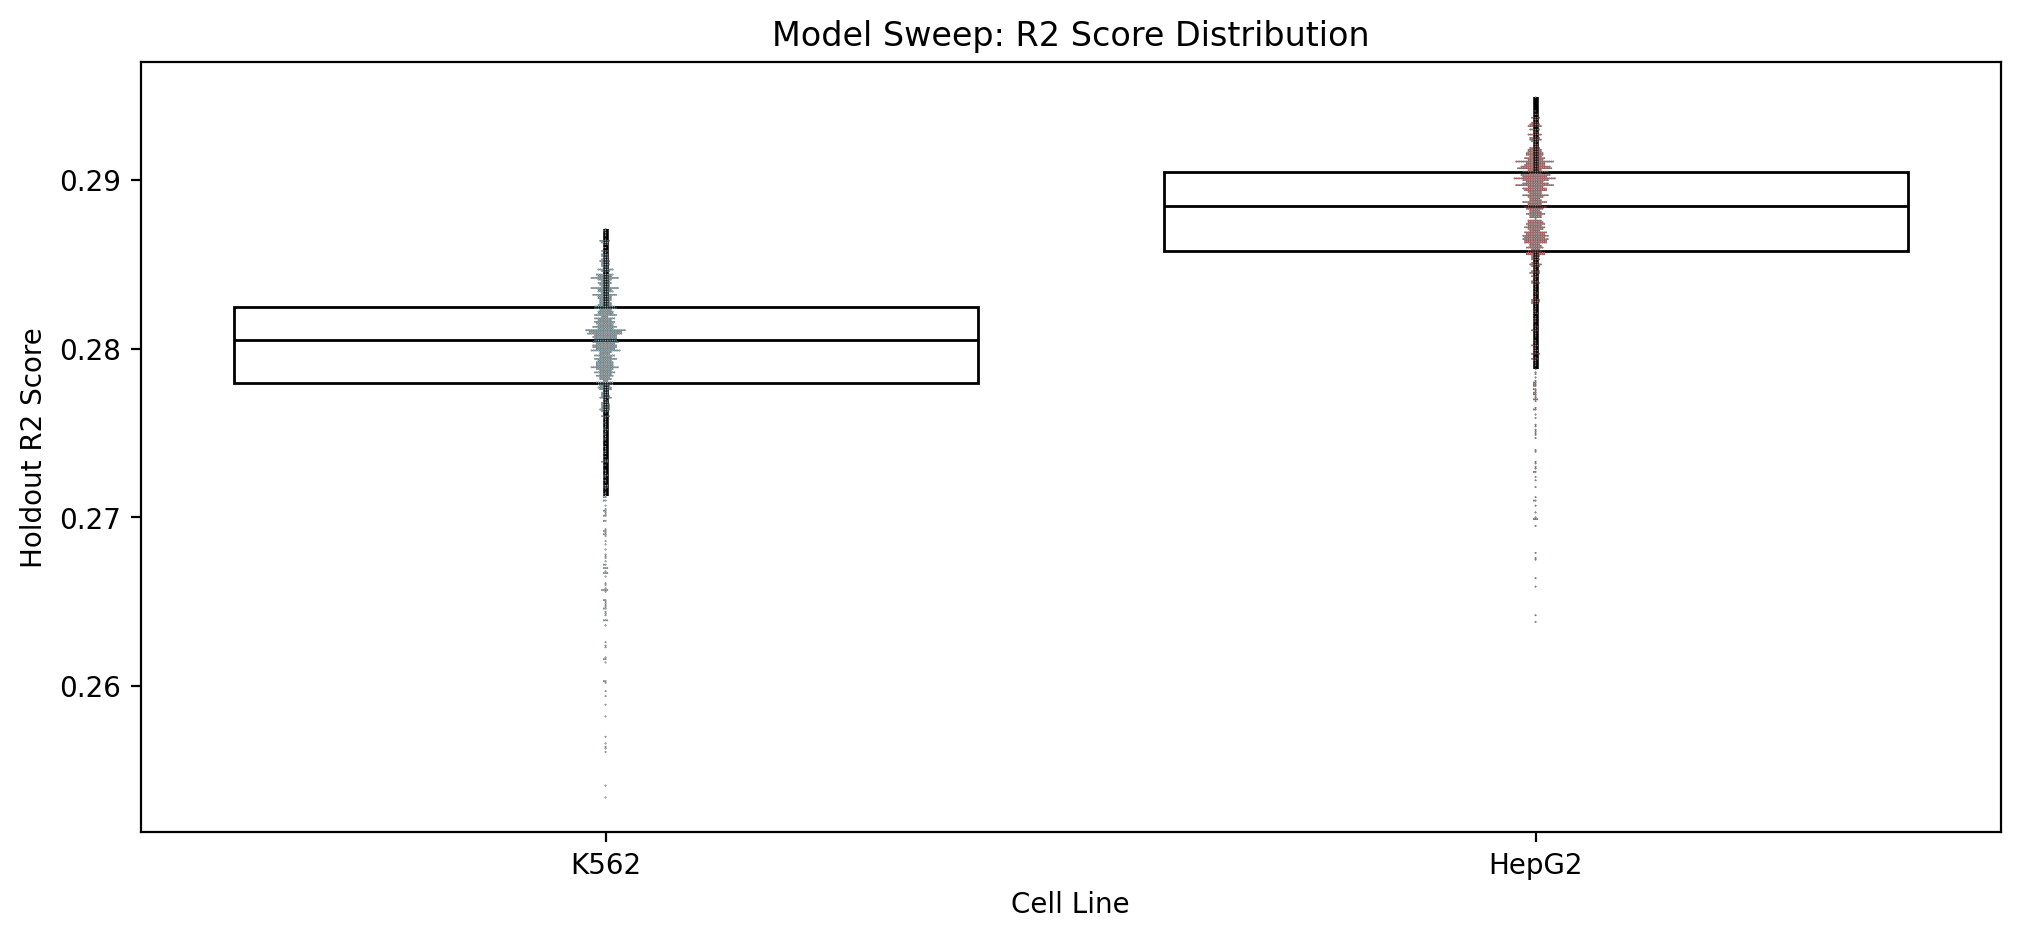

In [7]:
analyzer.plot_r2_distributions()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Dataset Hyperparameter Sweep</h1>

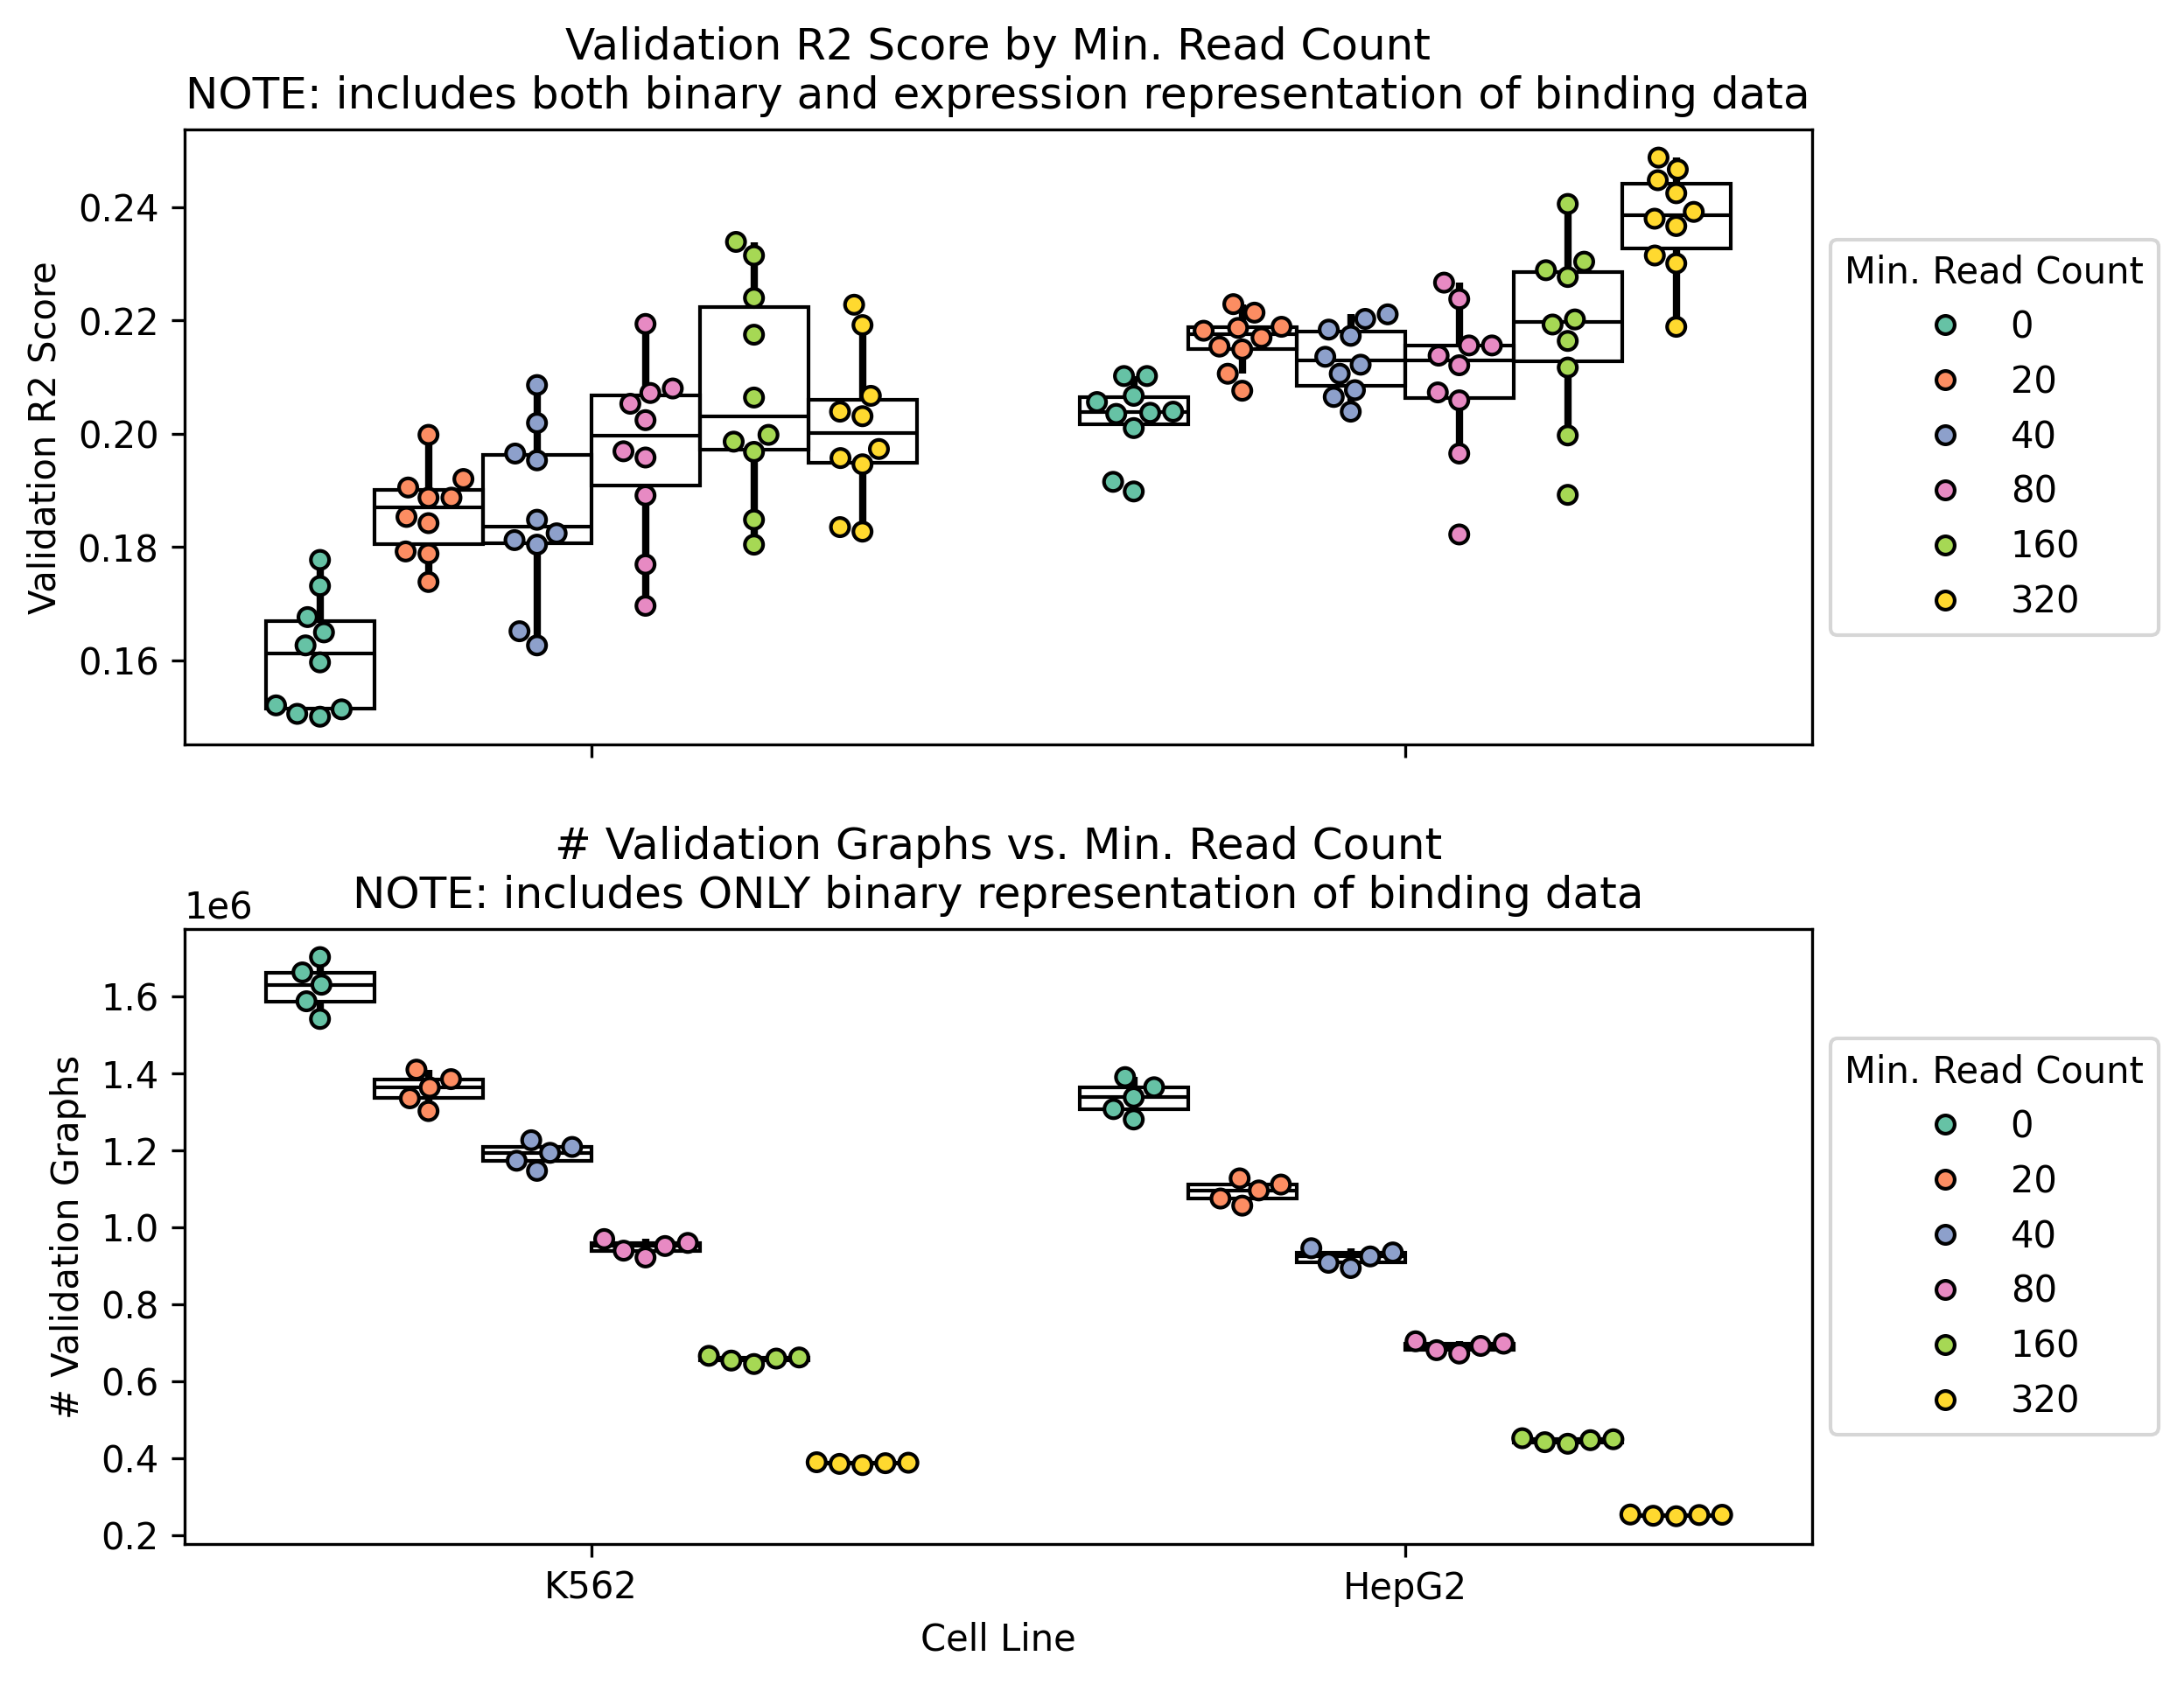

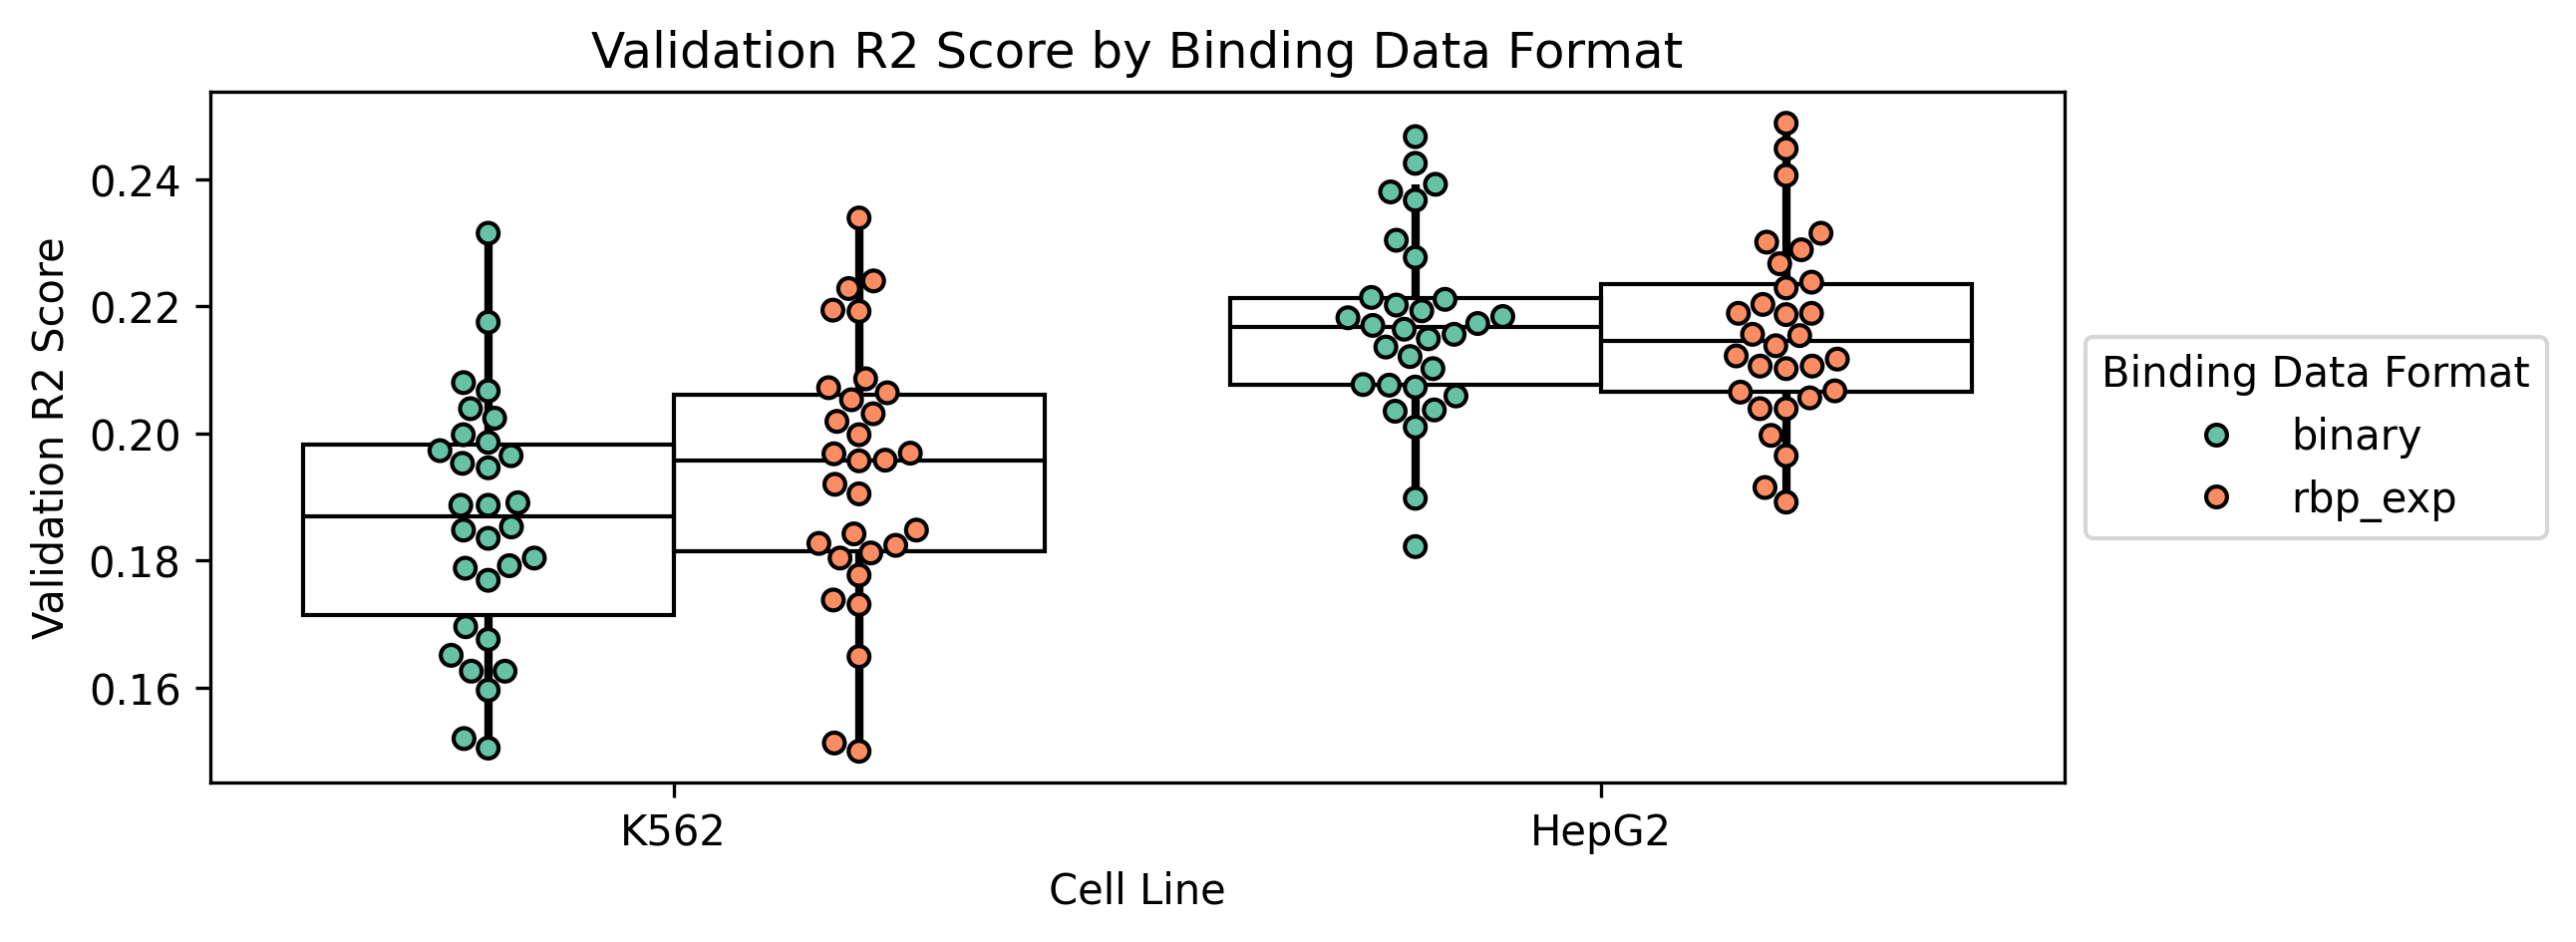

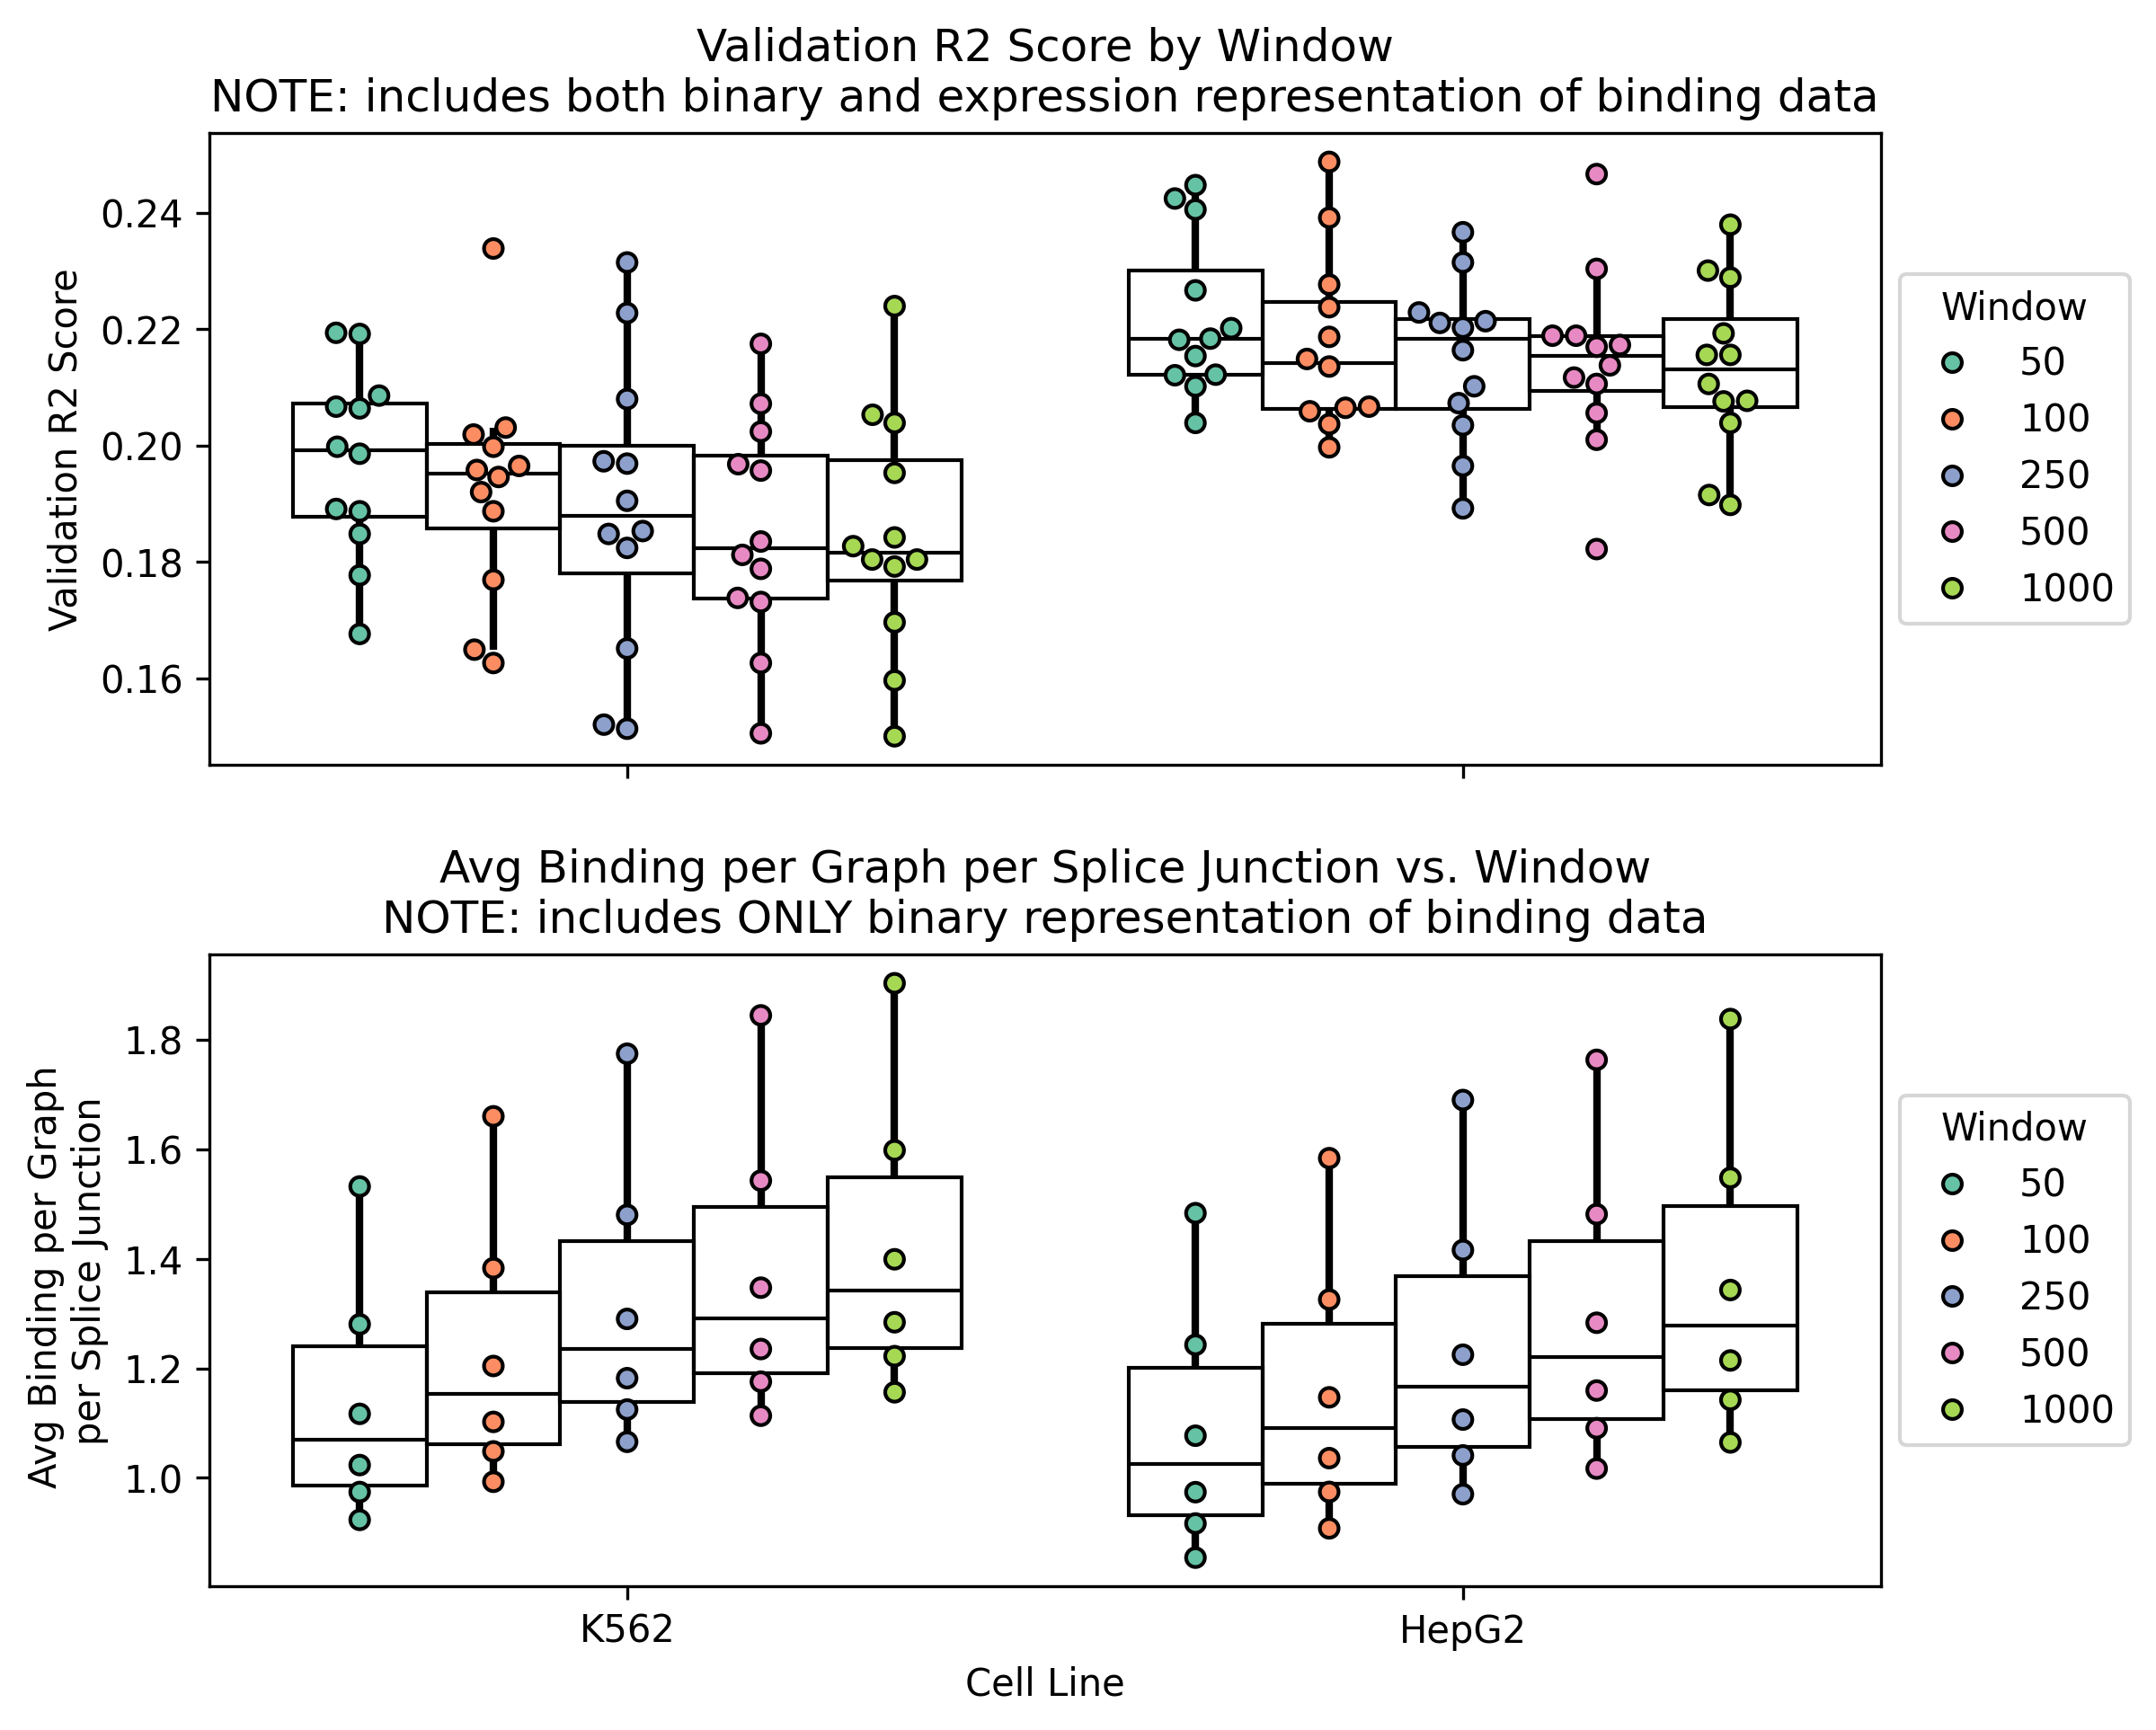

In [8]:
analyzer.plot_dataset_r2_per_covariate()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Model Hyperparameter Sweeps</h1>

## 1D Range Sweeps

In [ ]:
# analyzer.plot_1D_range_model_hyperparameter_sweeps()

## Inner Fold Splitting Robustness

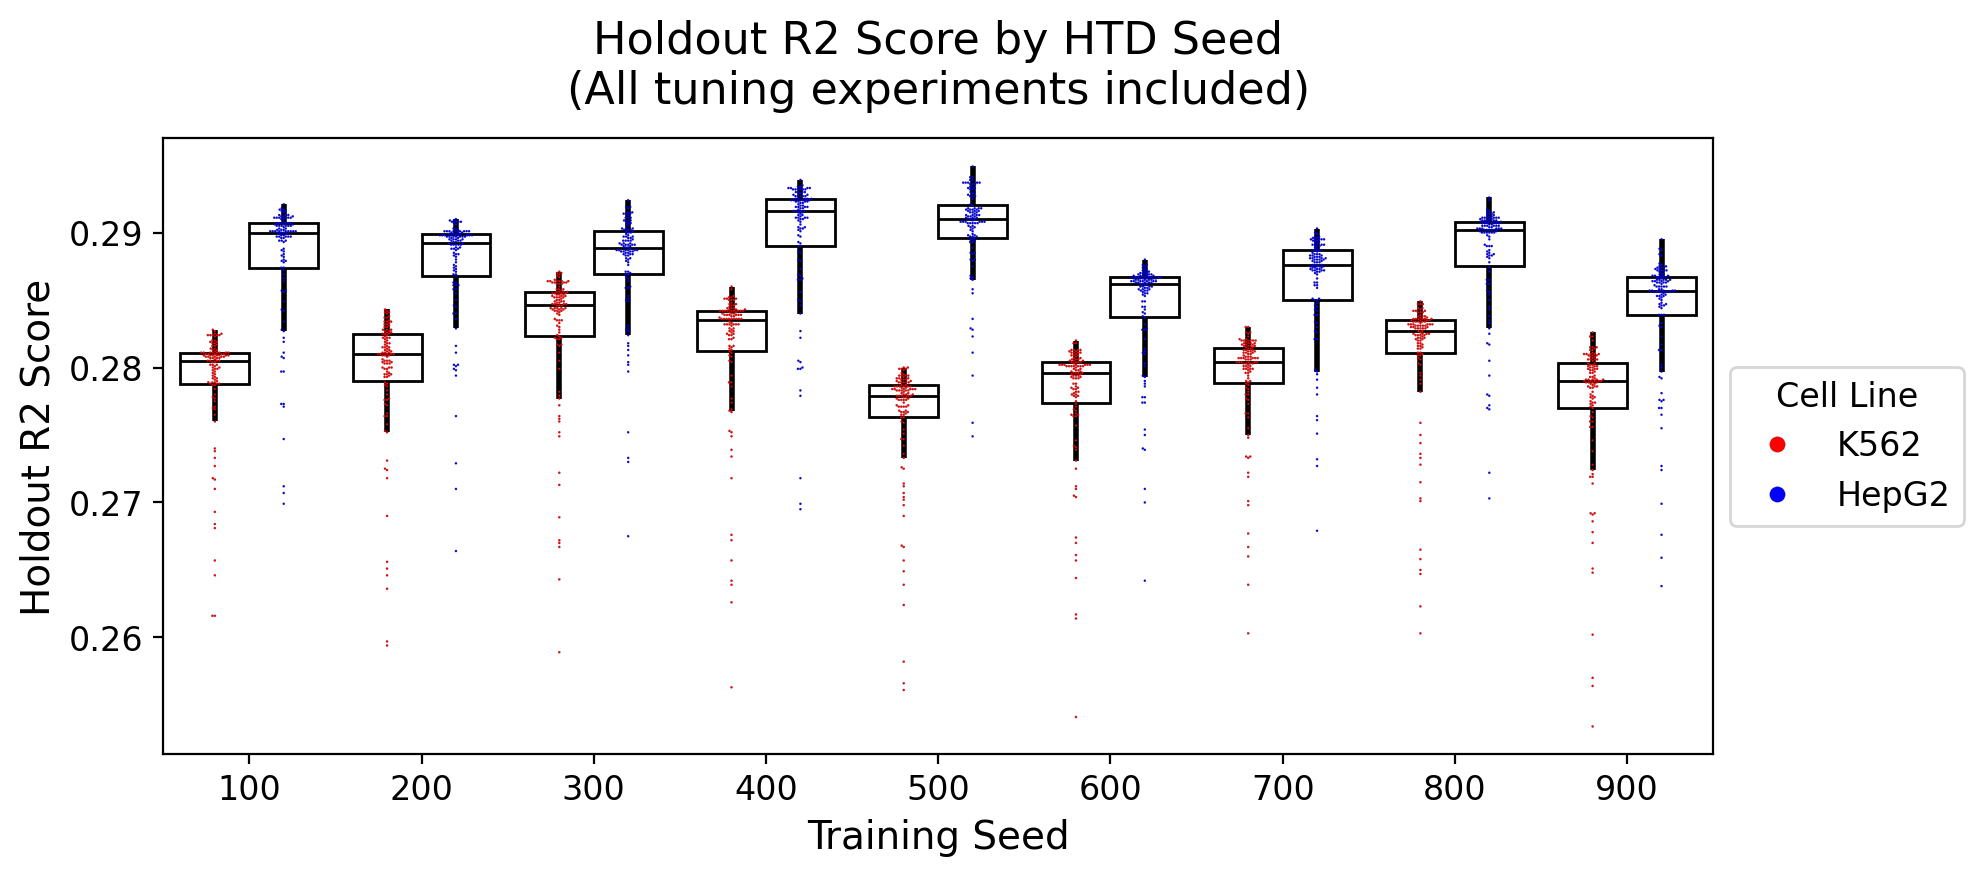

In [9]:
analyzer.plot_inner_fold_seed_r2_results()

## 1D Plotting of Sweep Results

2025-04-08 11:07:49.990 | INFO     | dataset_and_model_parameter_chooser:plot_interrelated_model_hyperparameter_results_in_1D:487 - Plotting for sweep: 1:early_stopping_rounds-learning_rate-max_depth


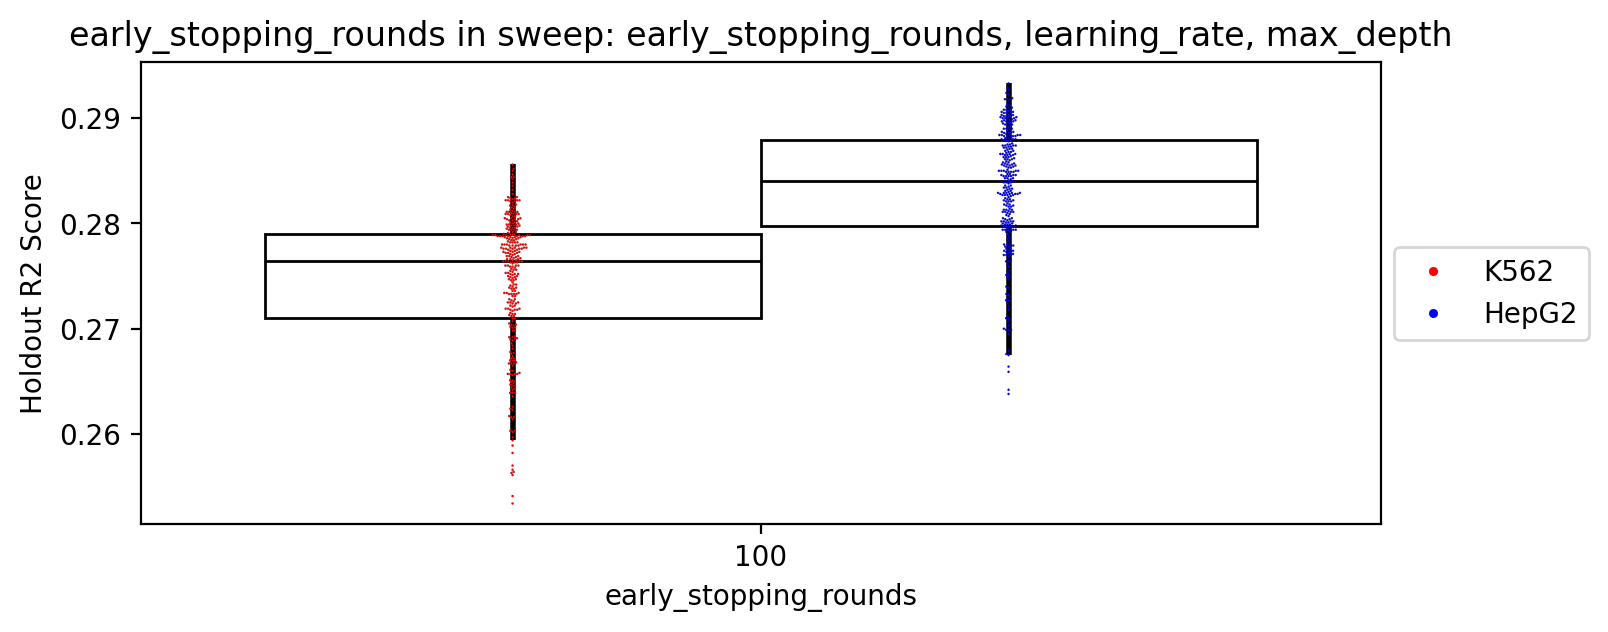

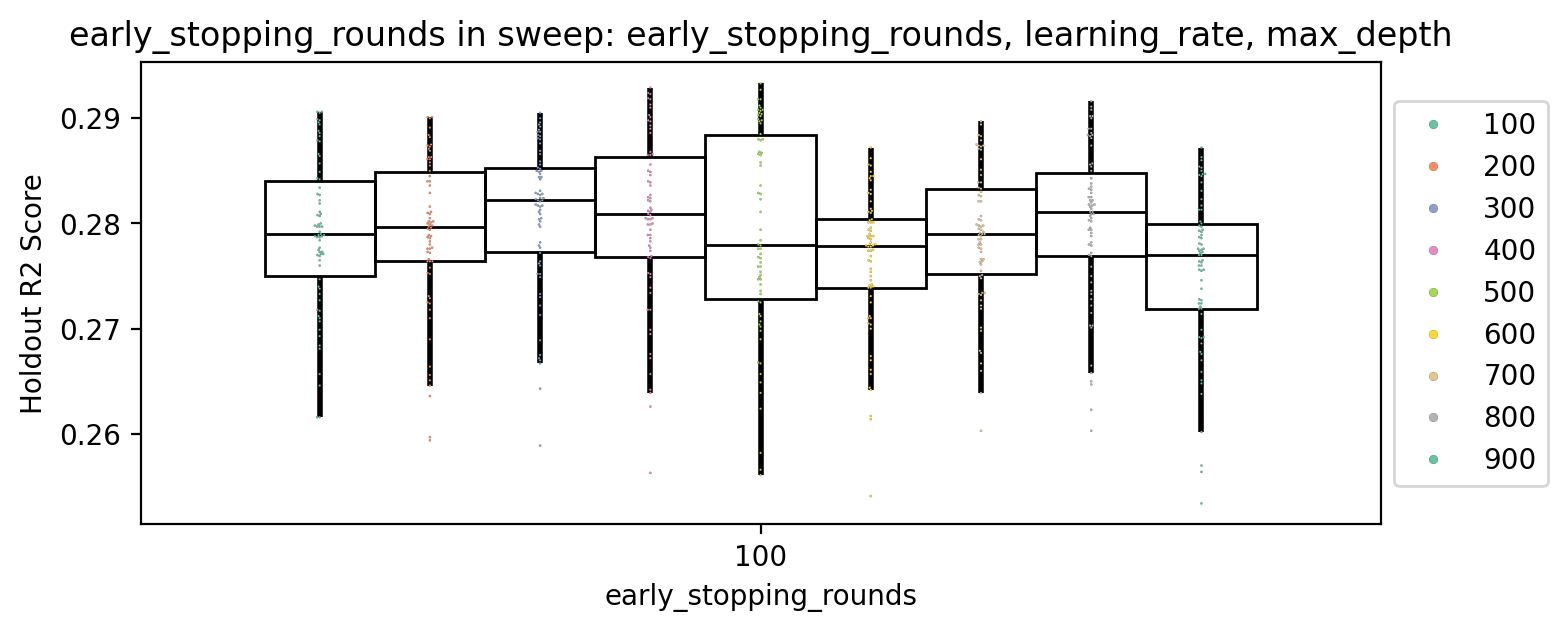

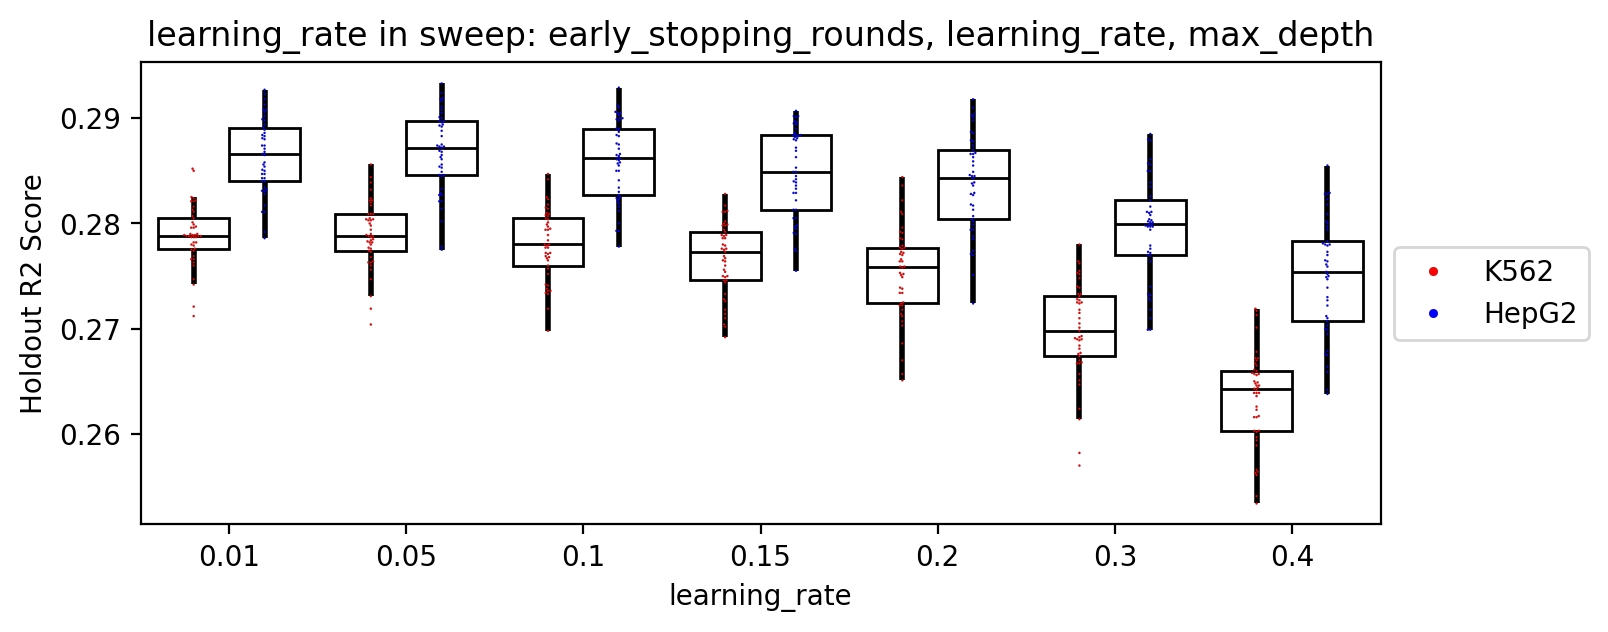

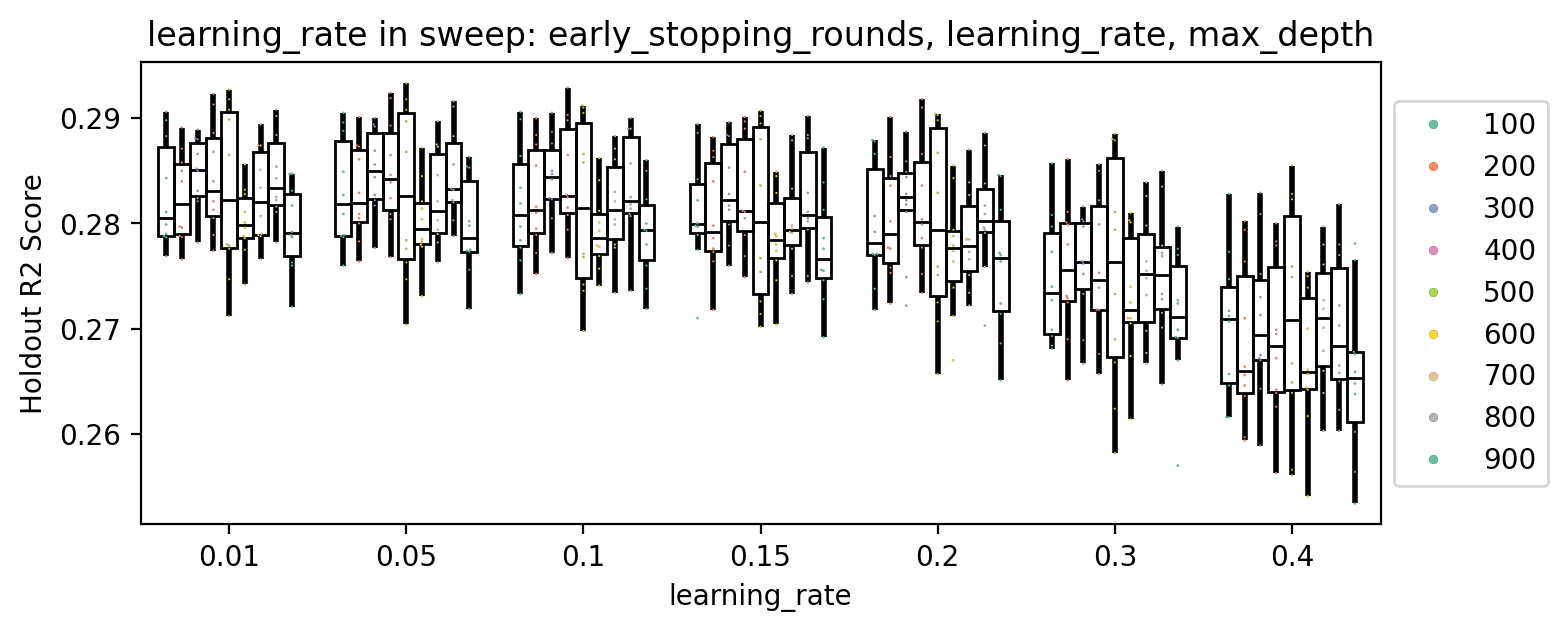

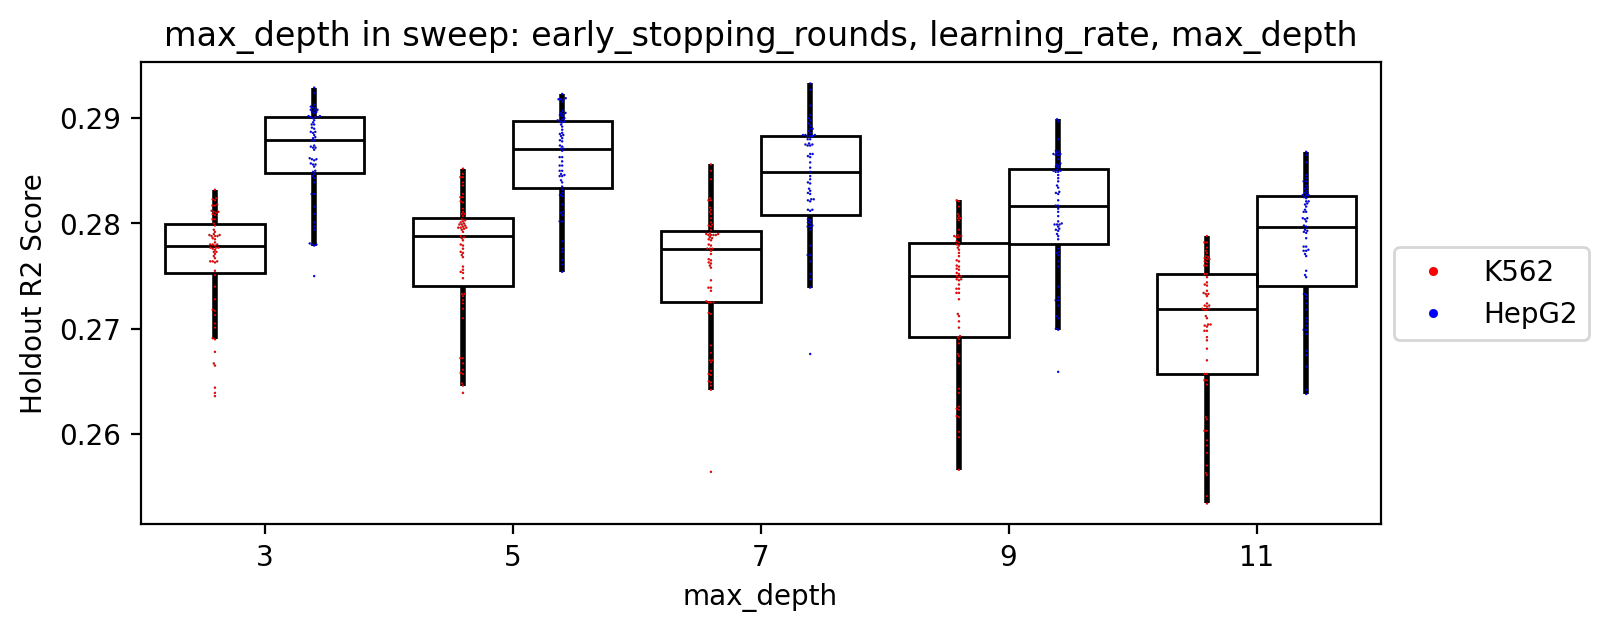

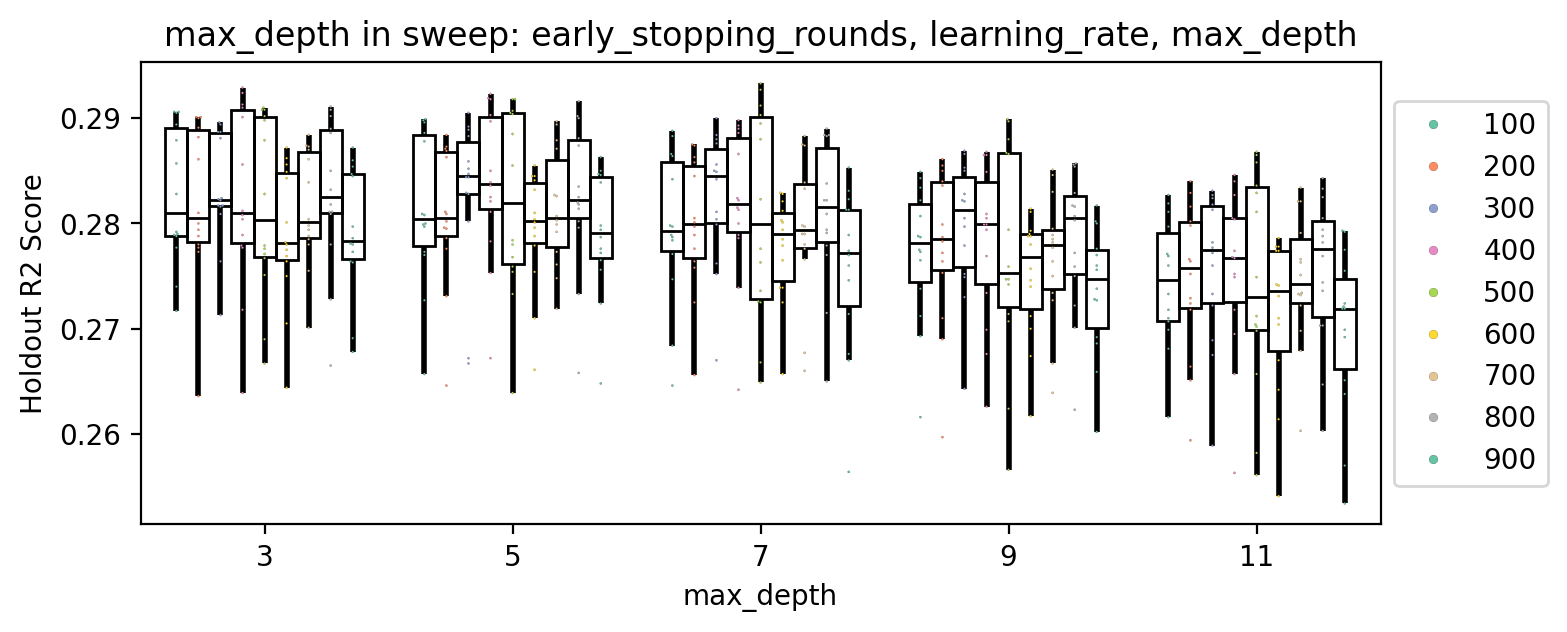

2025-04-08 11:07:56.236 | INFO     | dataset_and_model_parameter_chooser:plot_interrelated_model_hyperparameter_results_in_1D:487 - Plotting for sweep: 2:min_child_weight-gamma


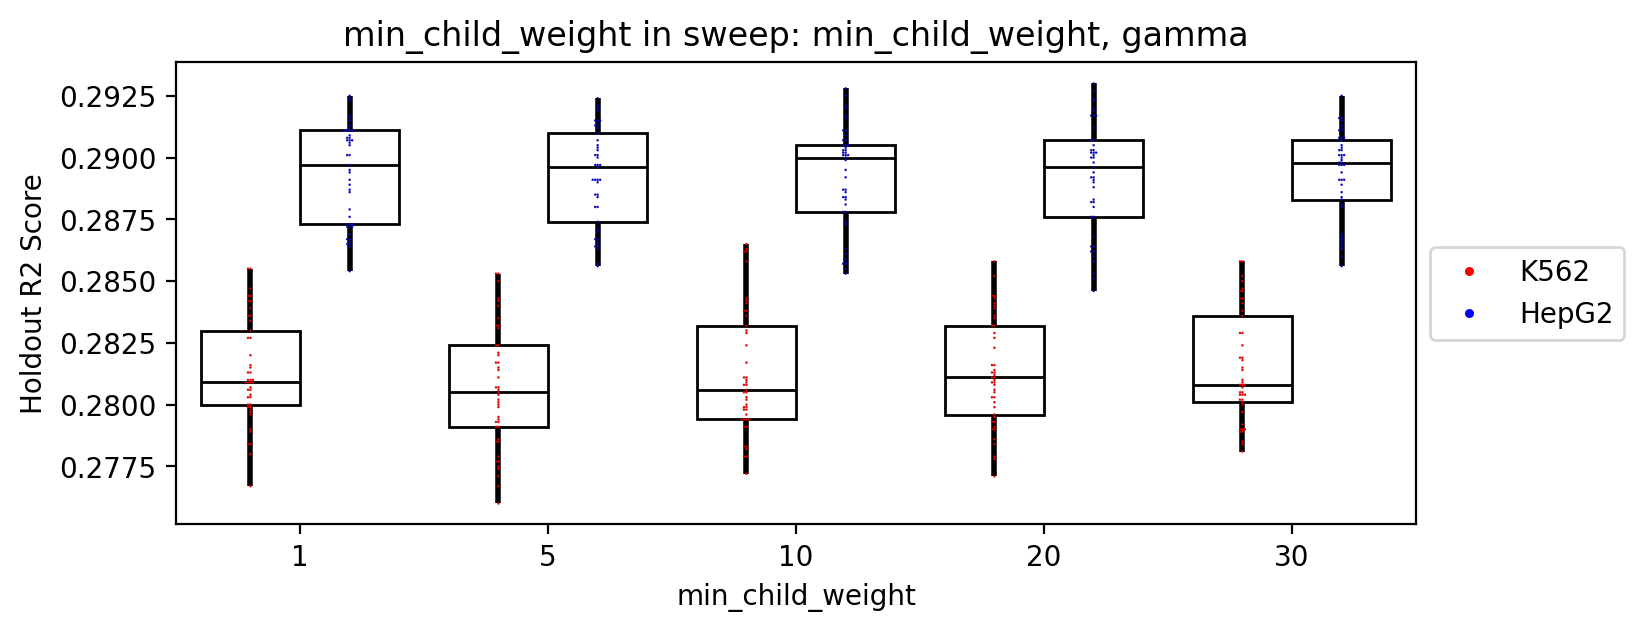

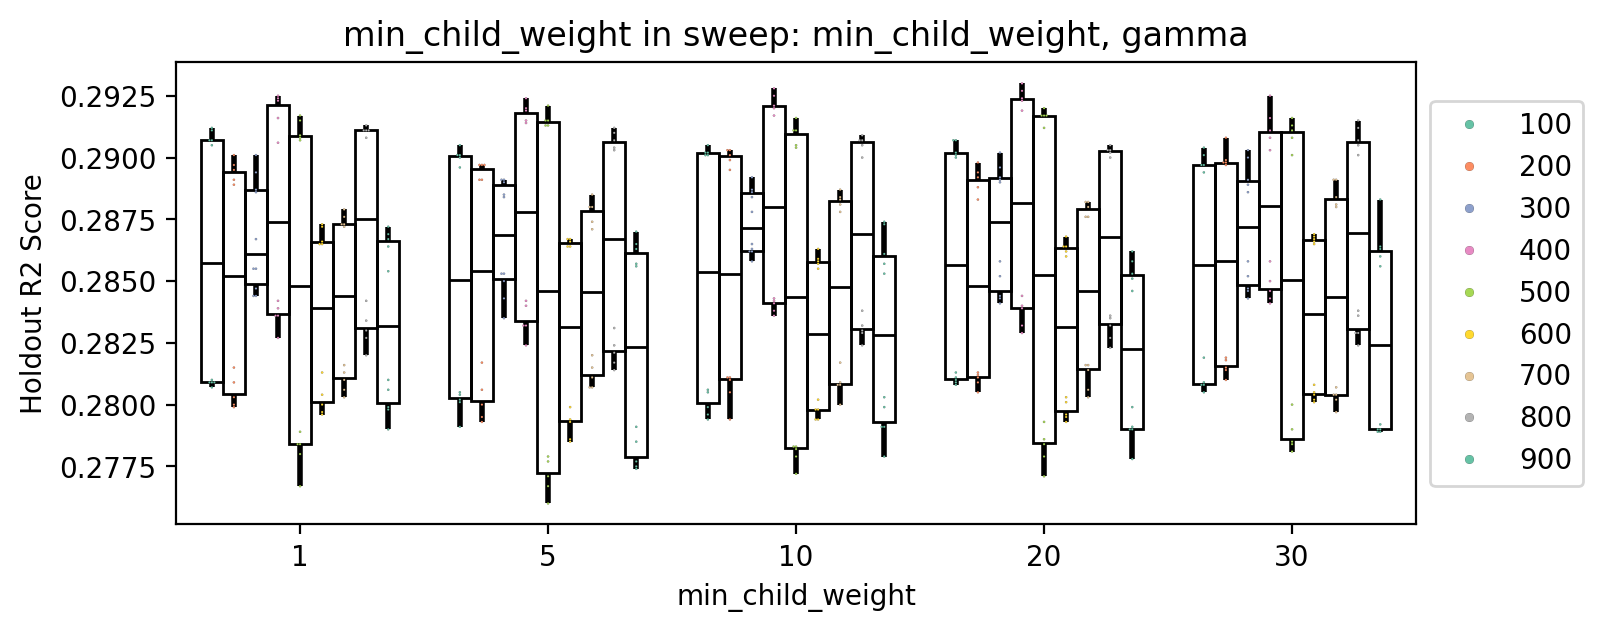

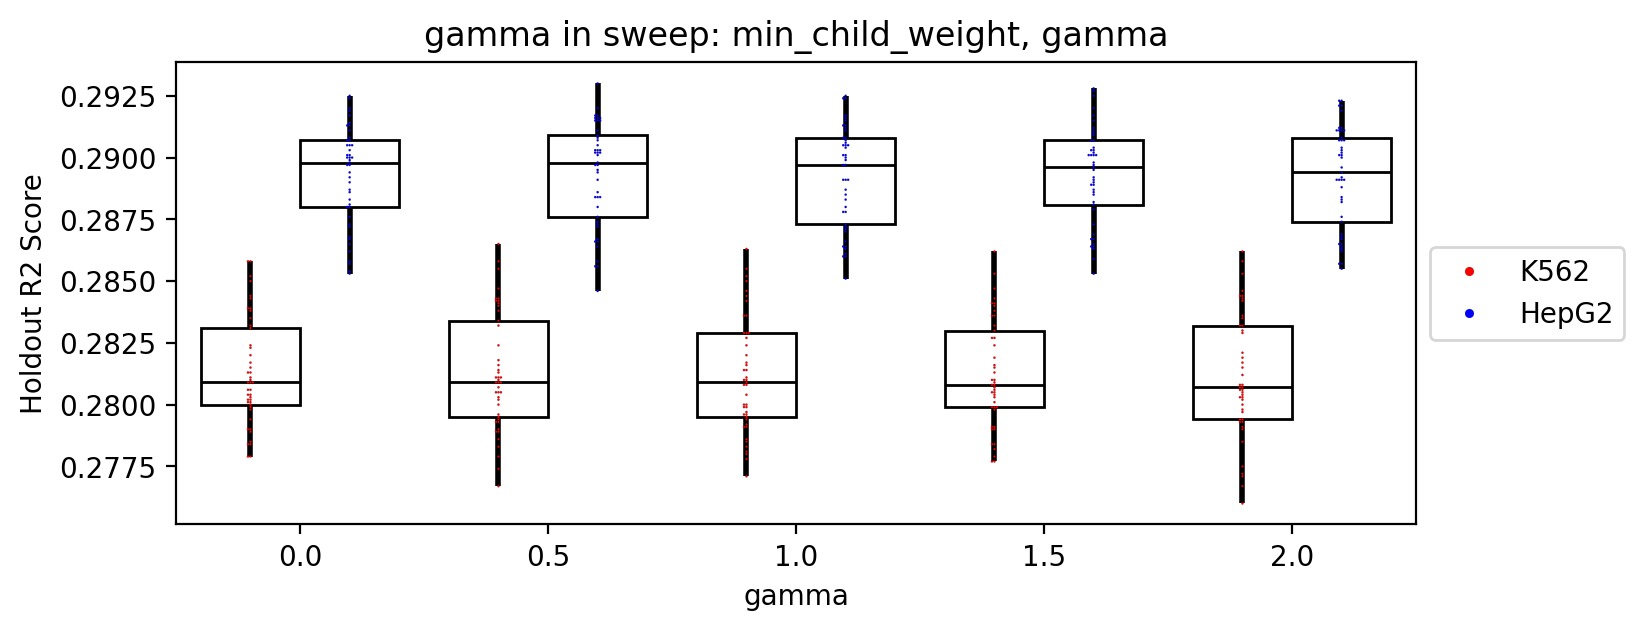

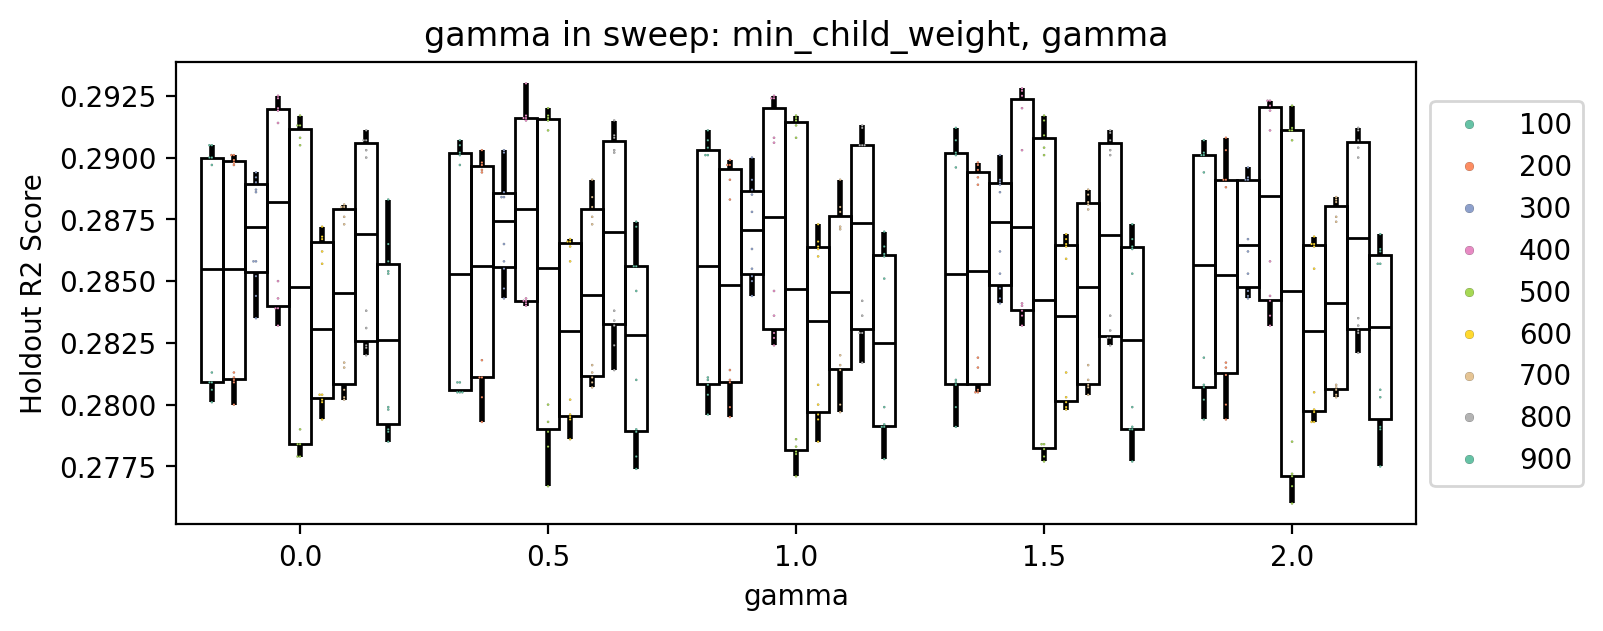

2025-04-08 11:07:59.800 | INFO     | dataset_and_model_parameter_chooser:plot_interrelated_model_hyperparameter_results_in_1D:487 - Plotting for sweep: 3:subsample-colsample_bytree


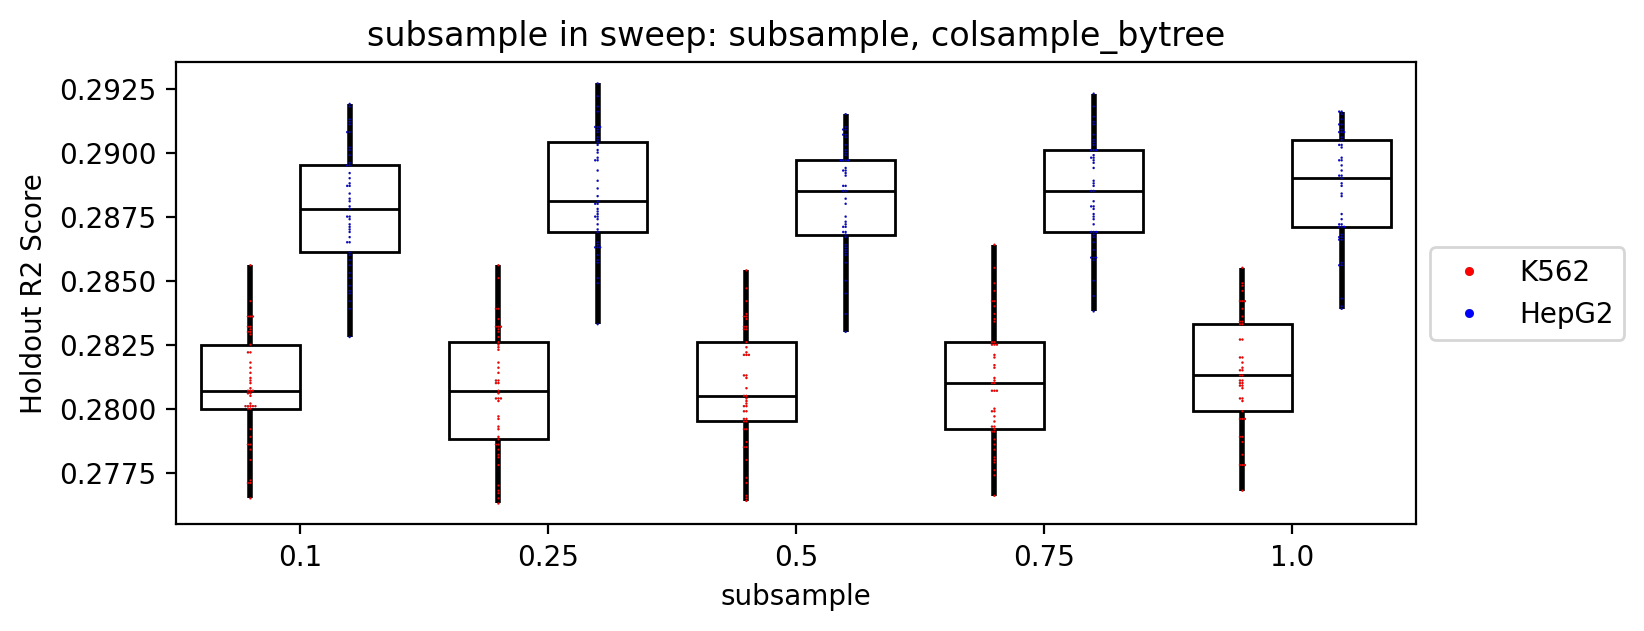

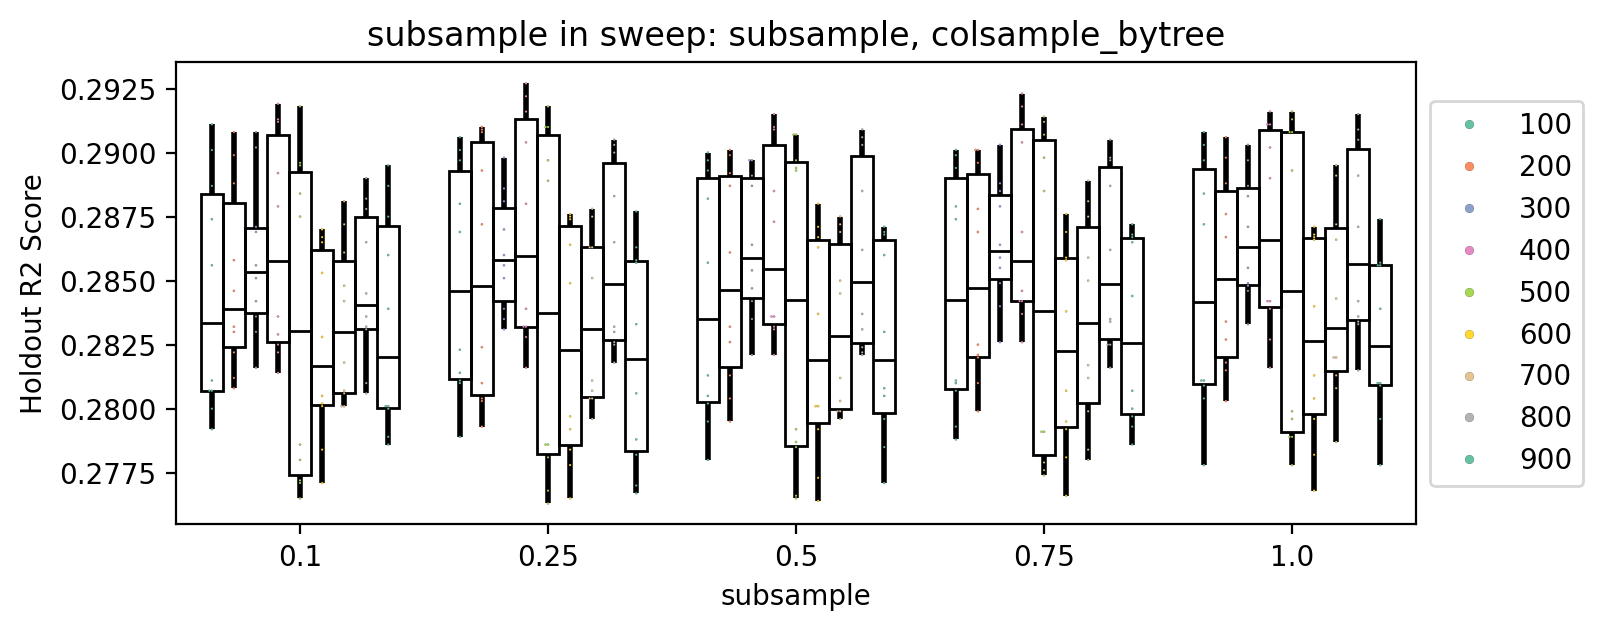

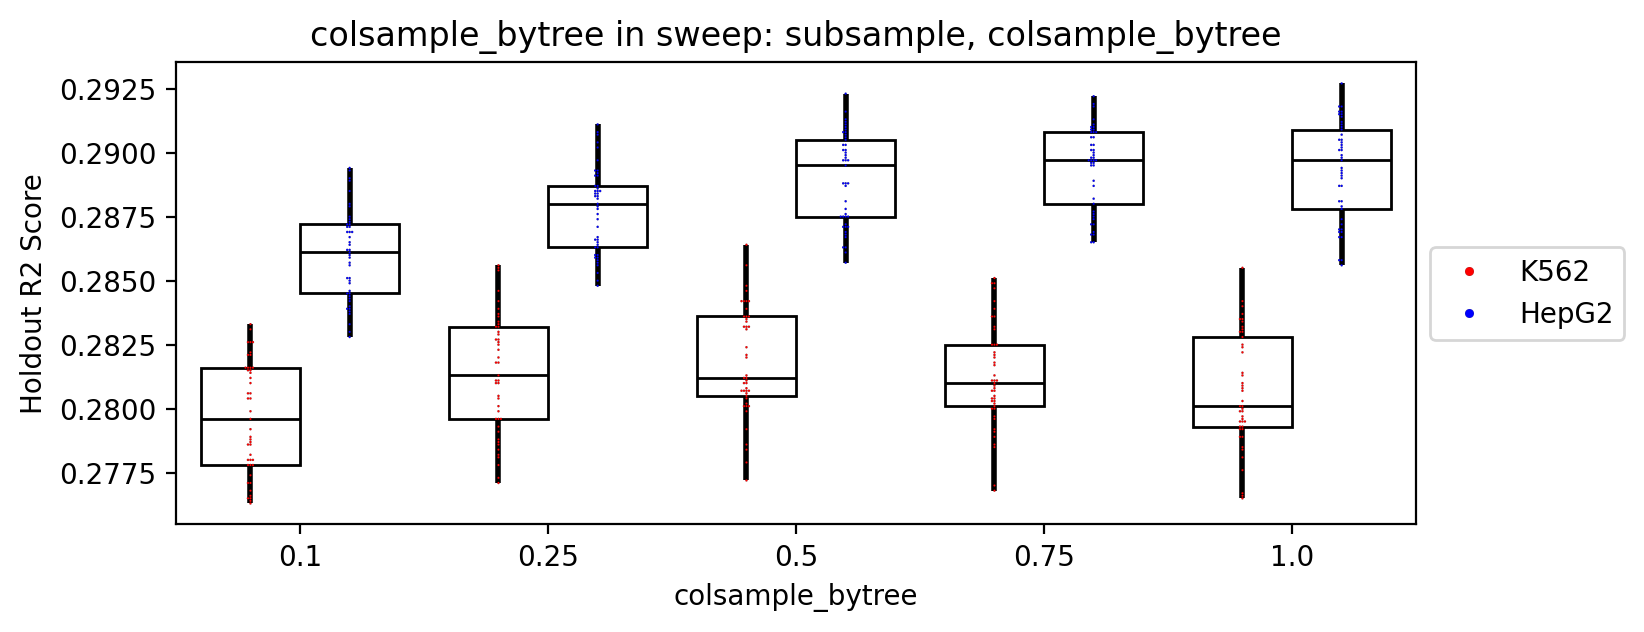

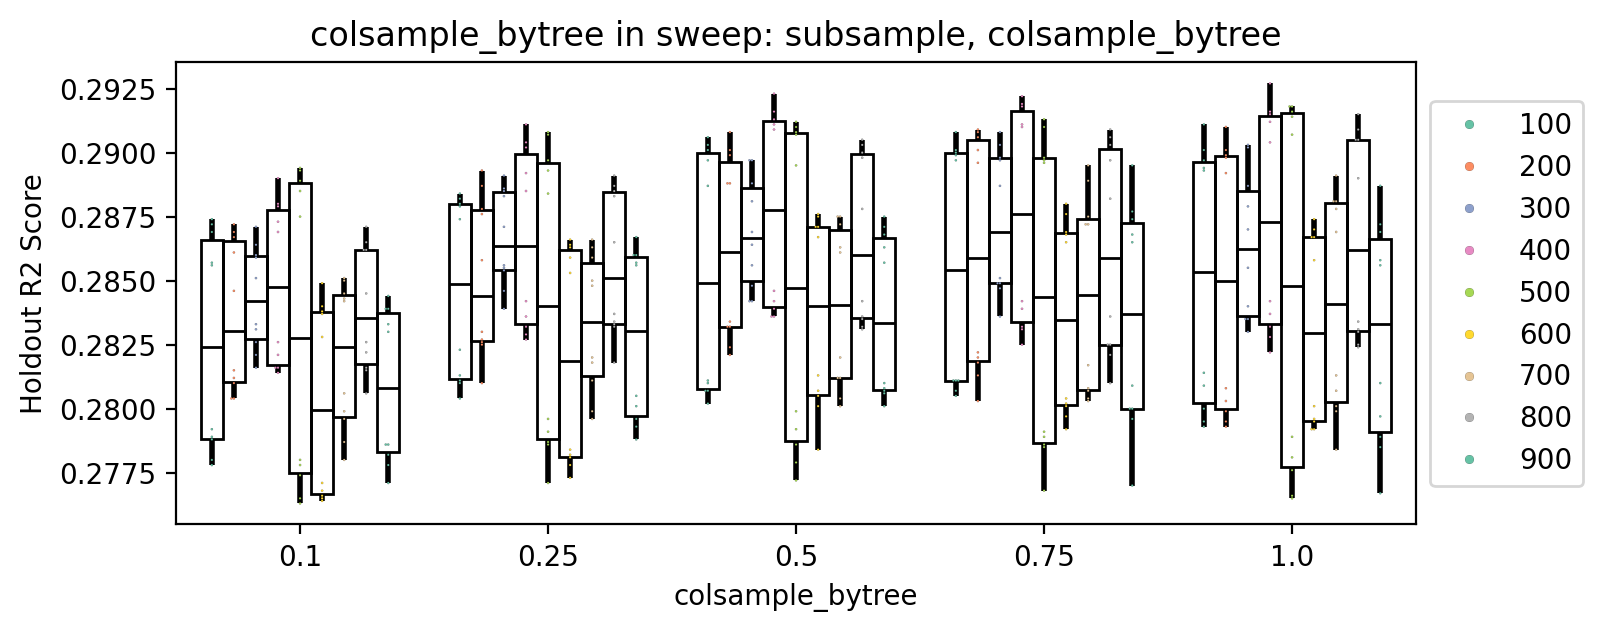

2025-04-08 11:08:03.562 | INFO     | dataset_and_model_parameter_chooser:plot_interrelated_model_hyperparameter_results_in_1D:487 - Plotting for sweep: 4:reg_alpha-reg_lambda


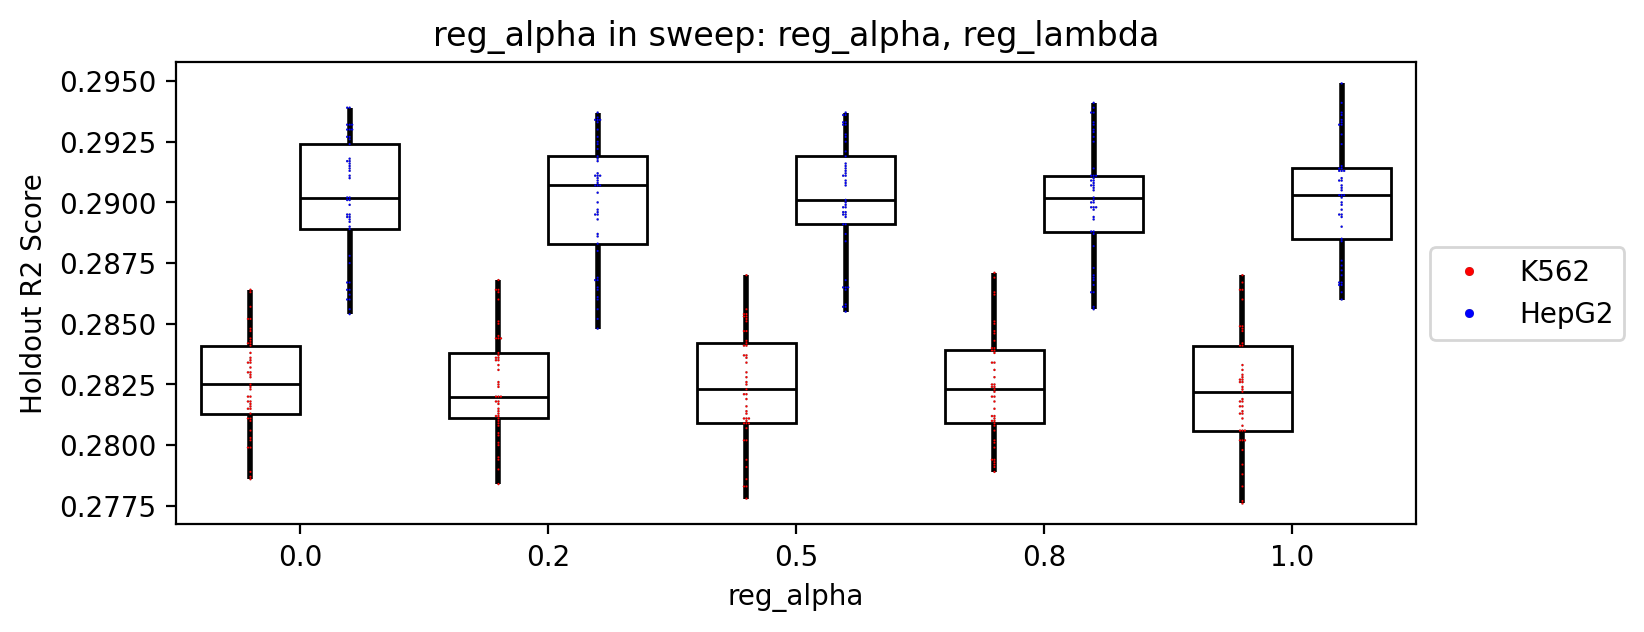

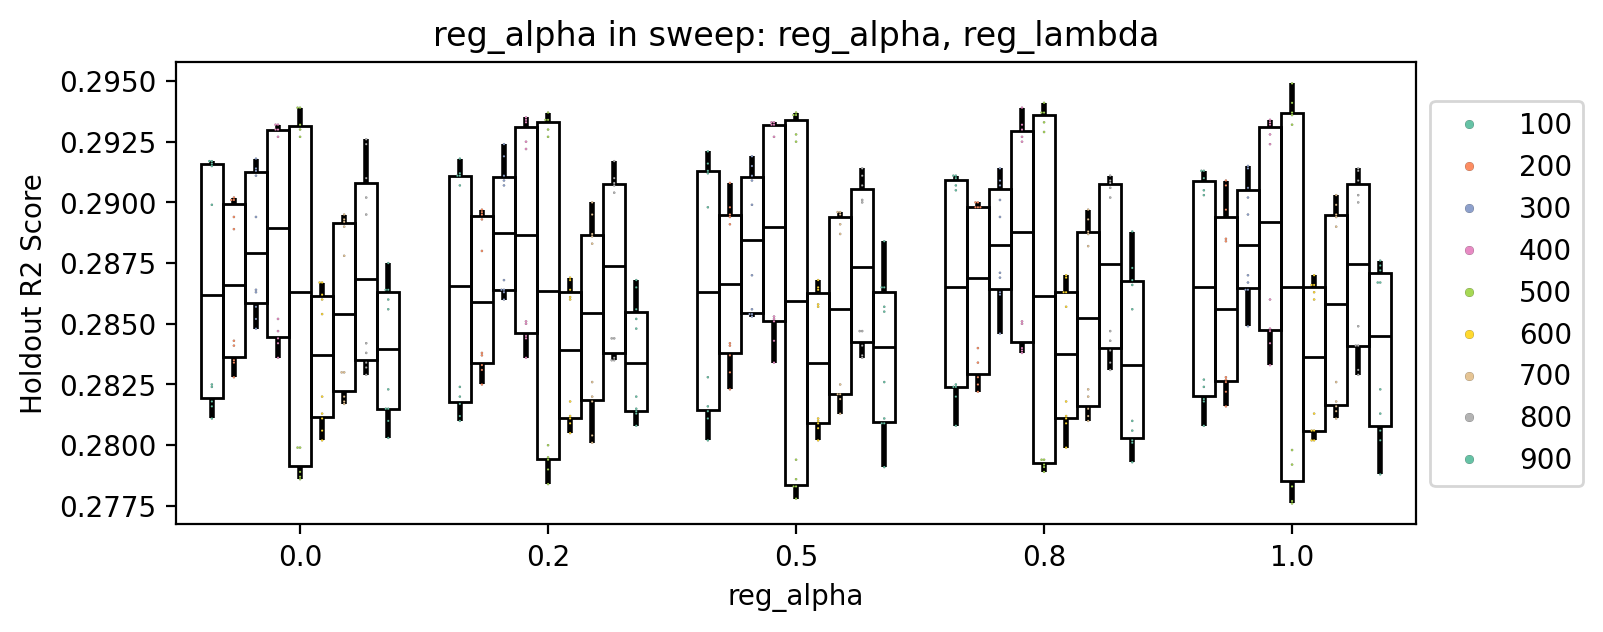

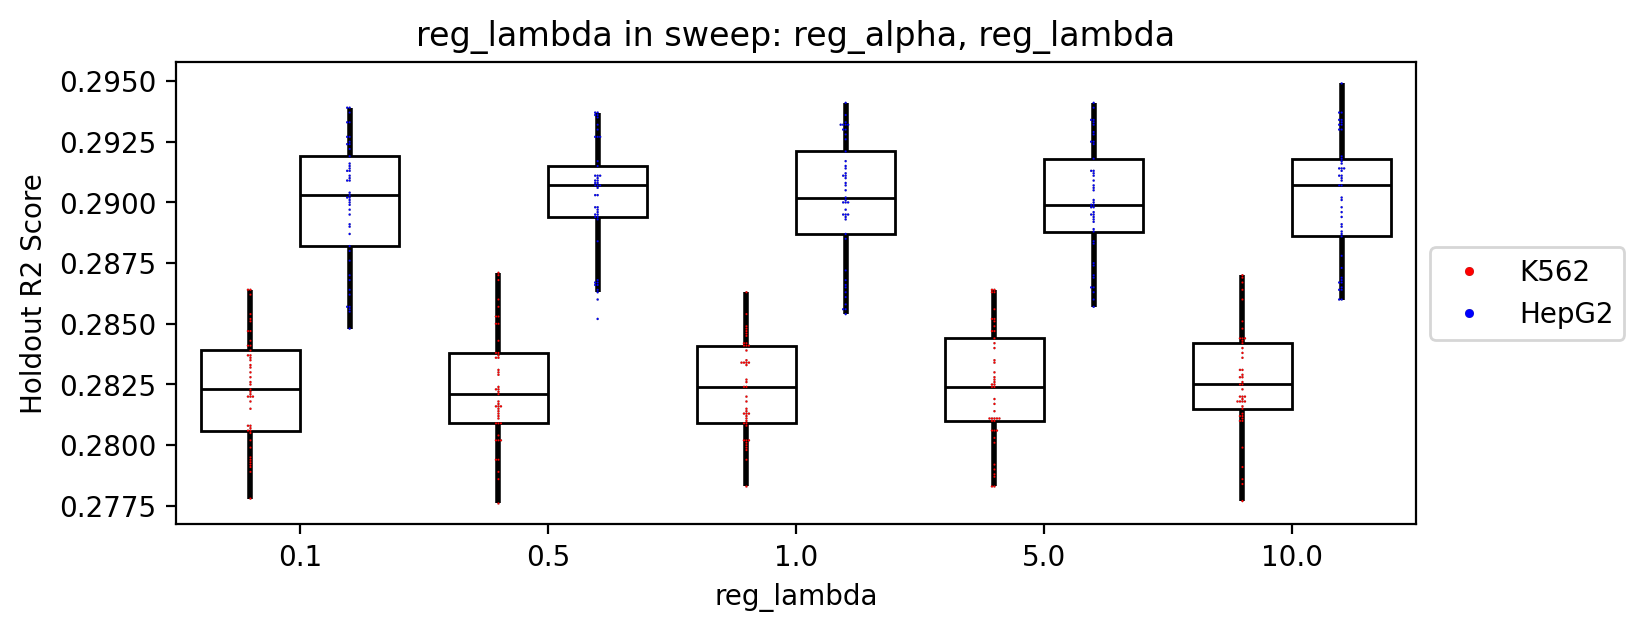

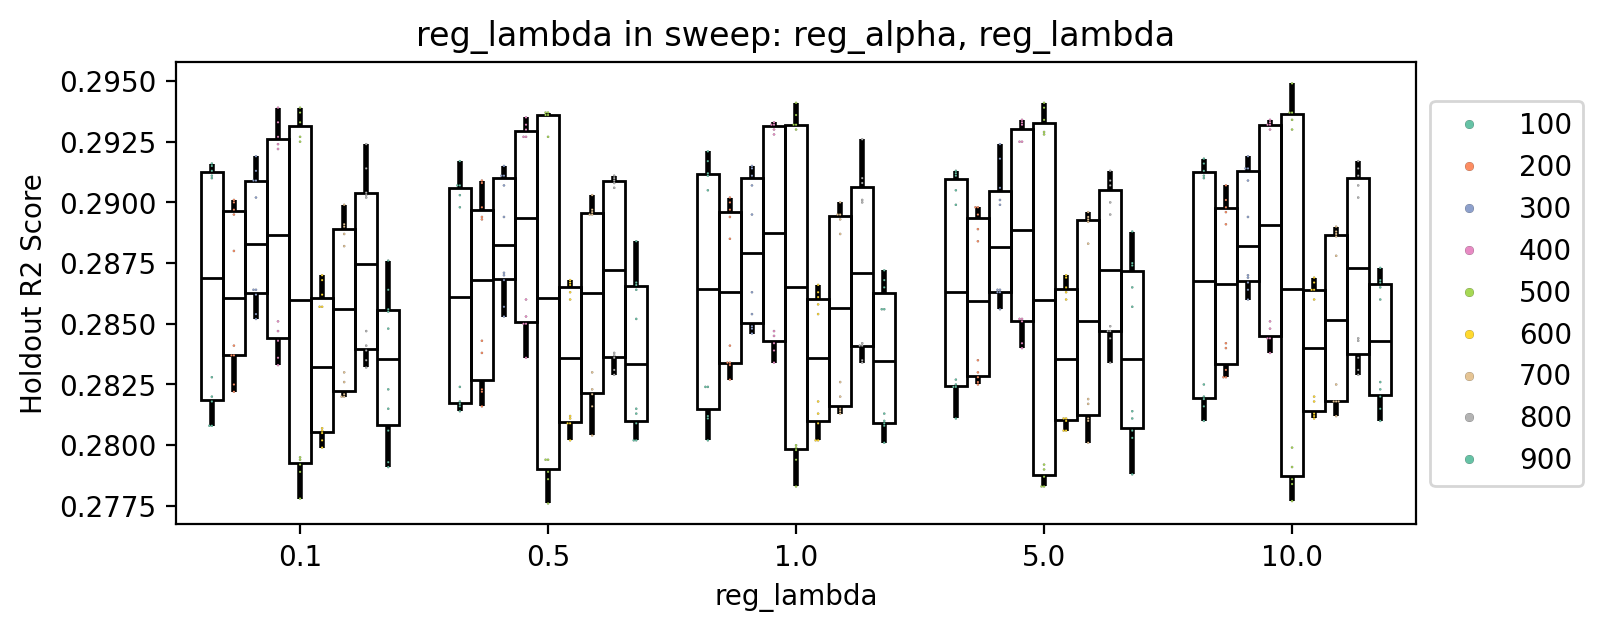

In [10]:
analyzer.plot_interrelated_model_hyperparameter_results_in_1D()

## Higher Dimensional Plotting of Model Sweep Results

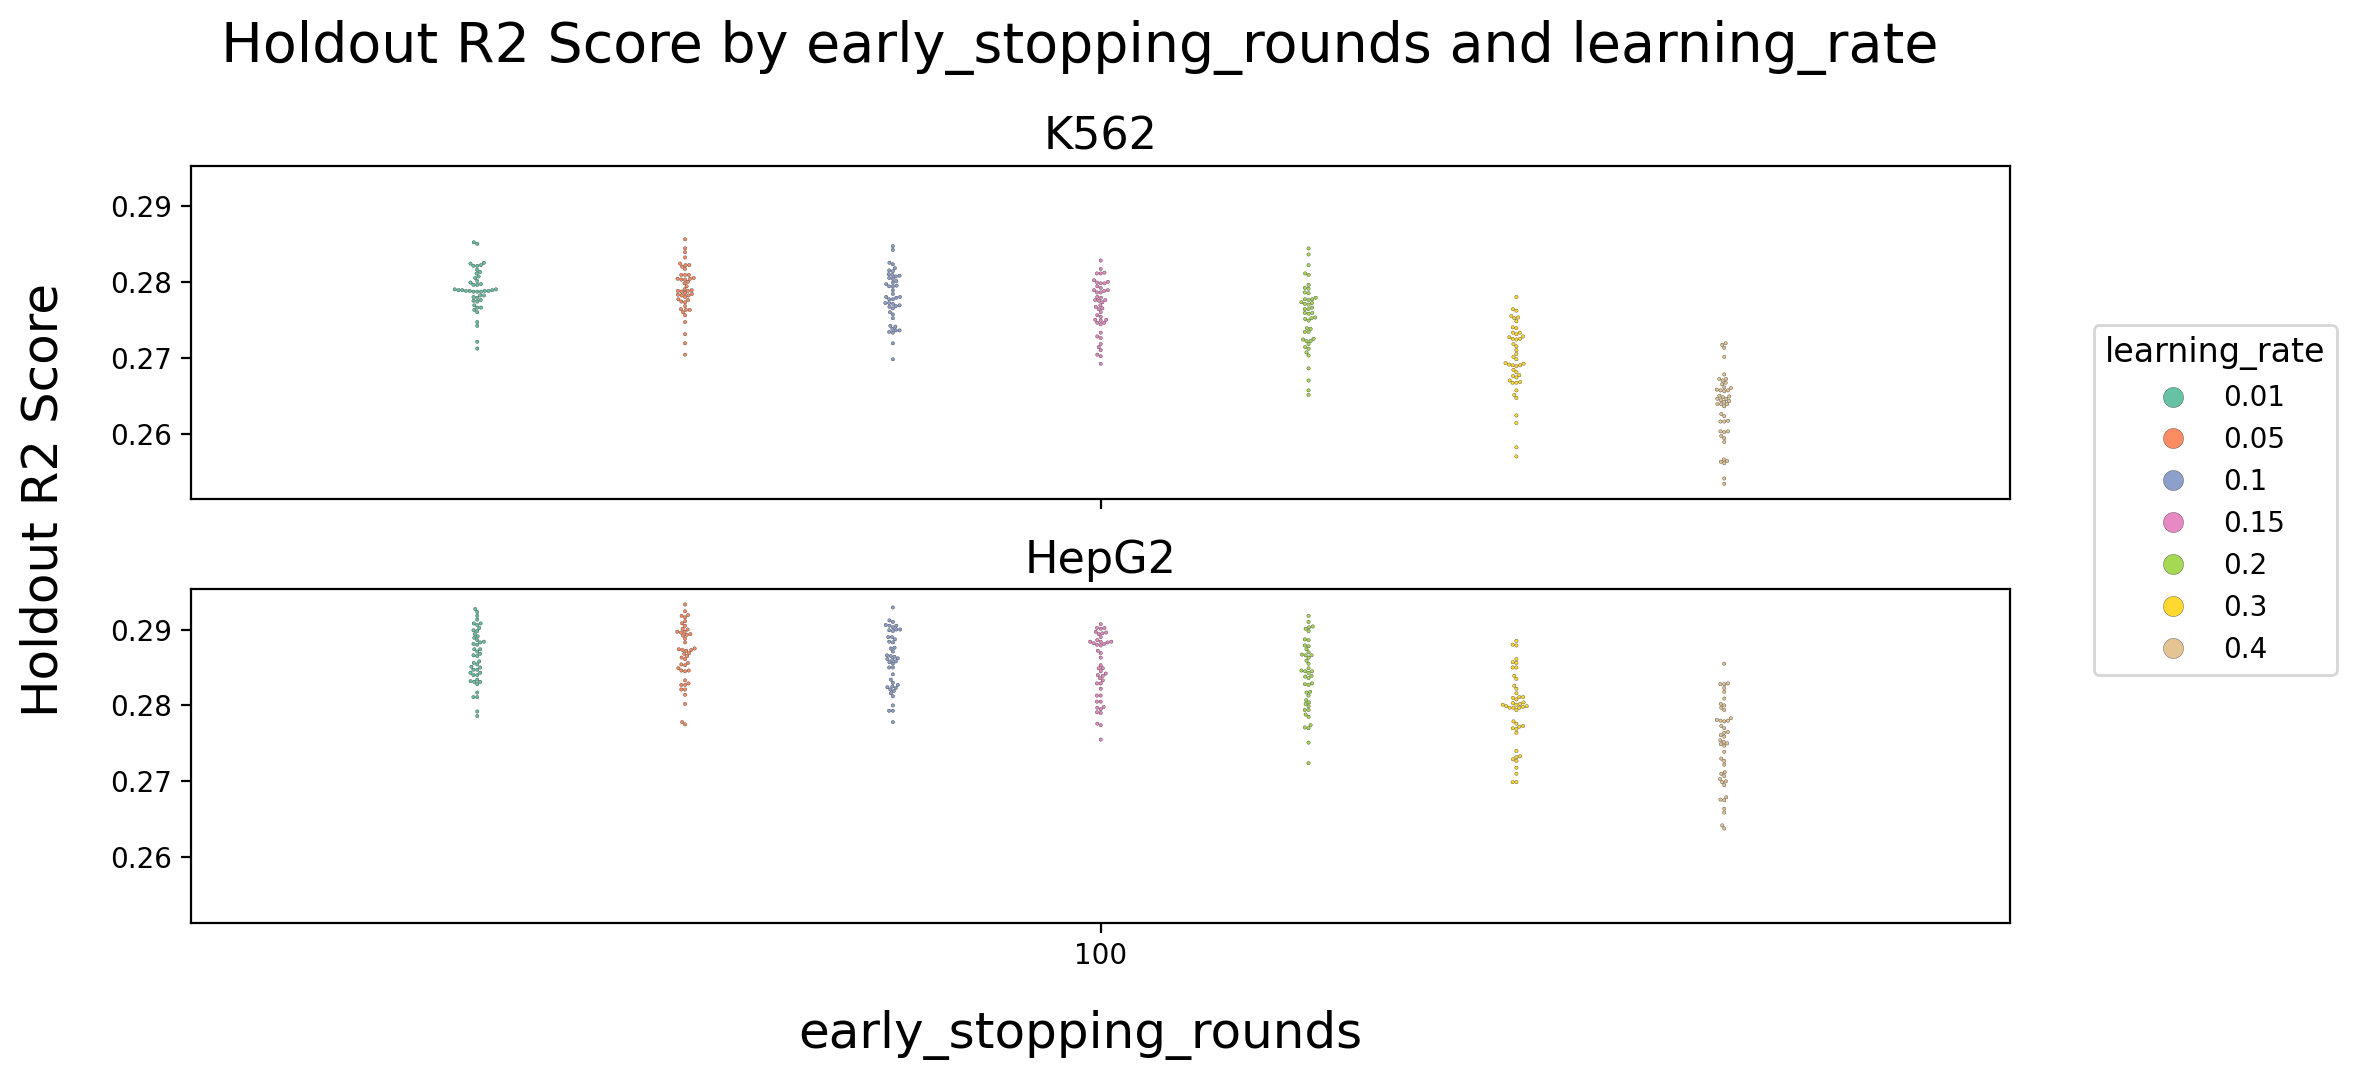

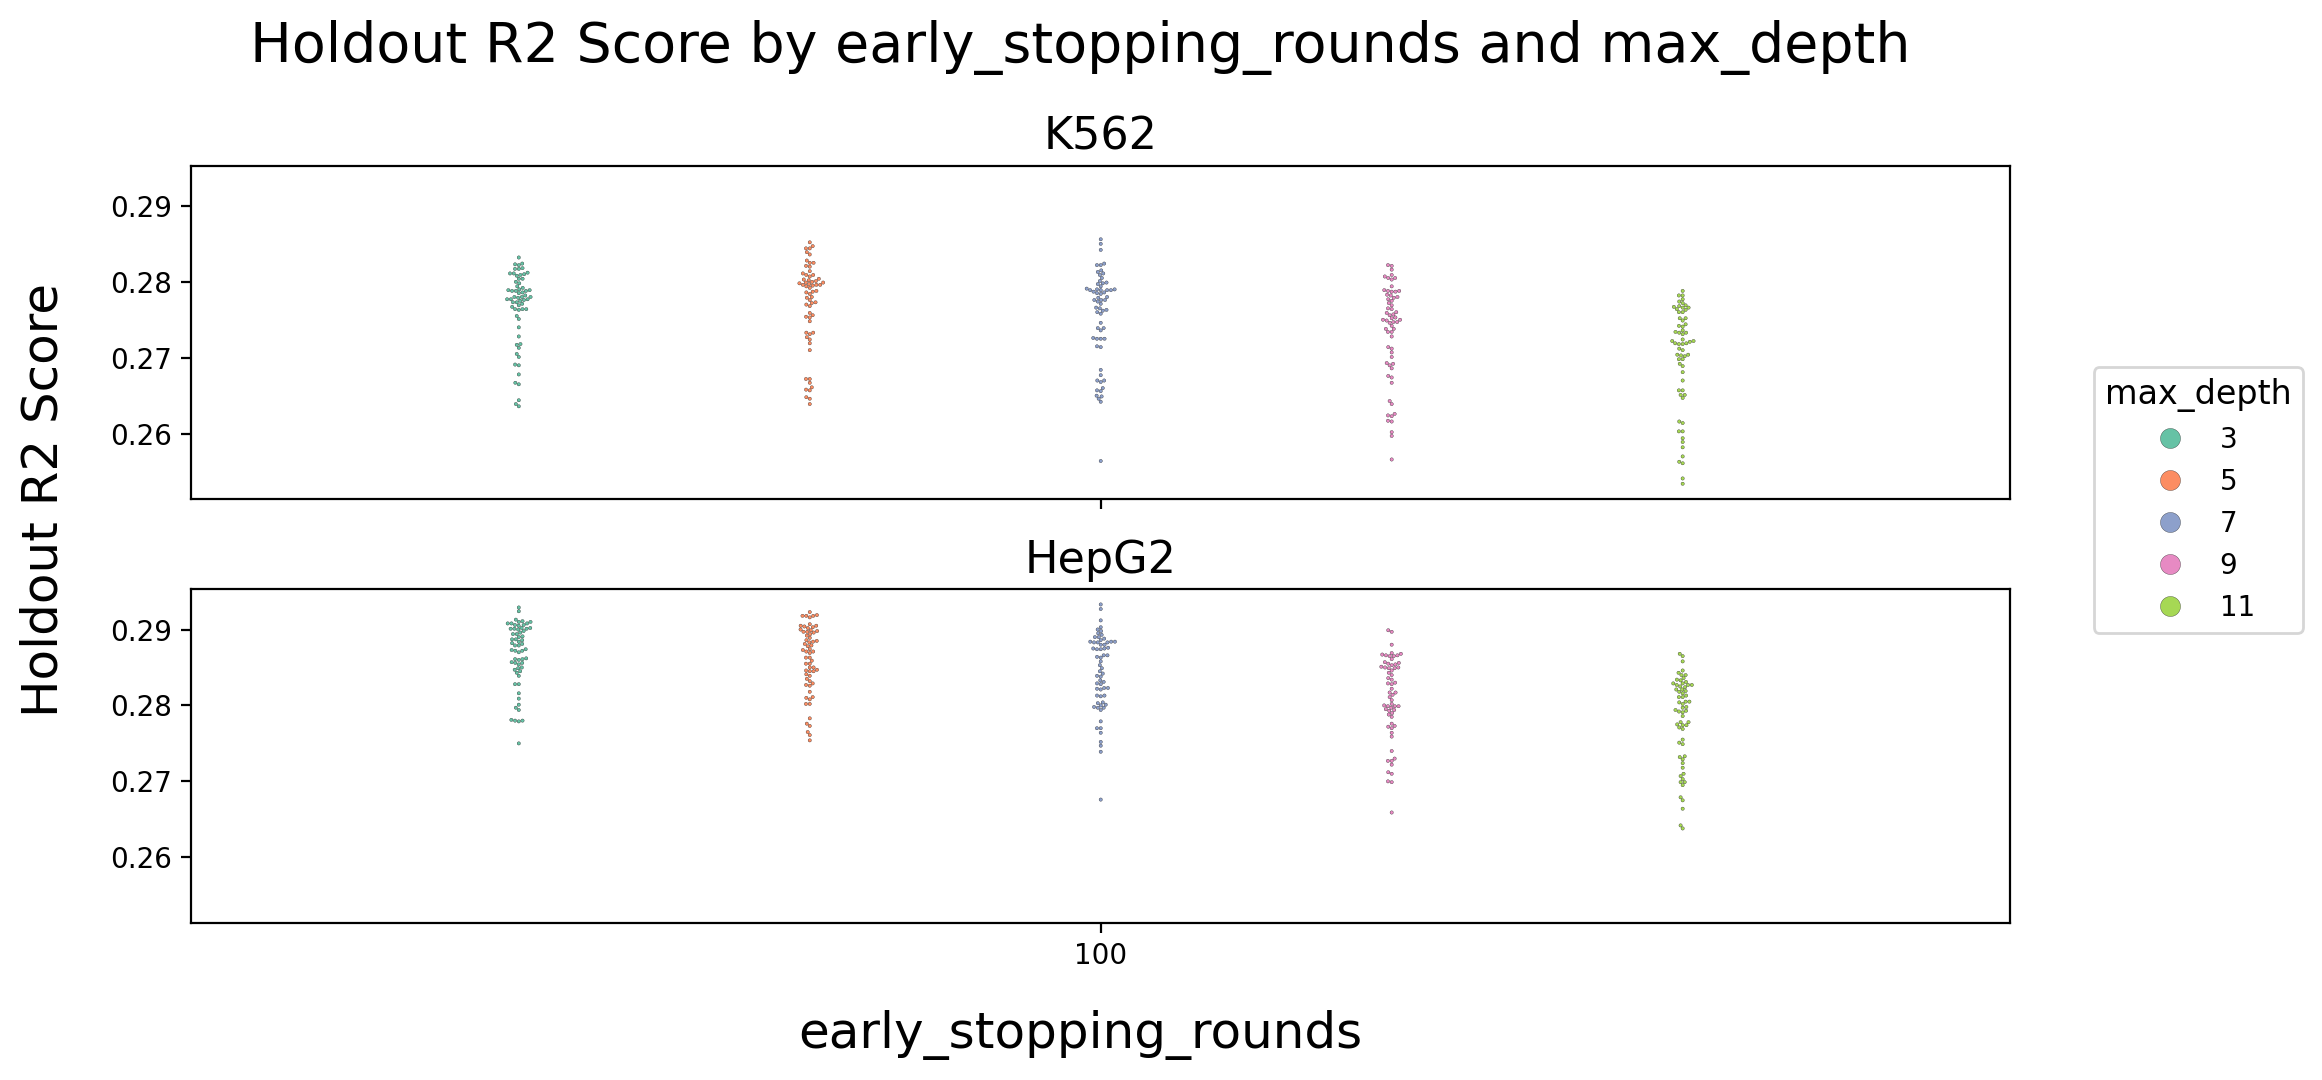

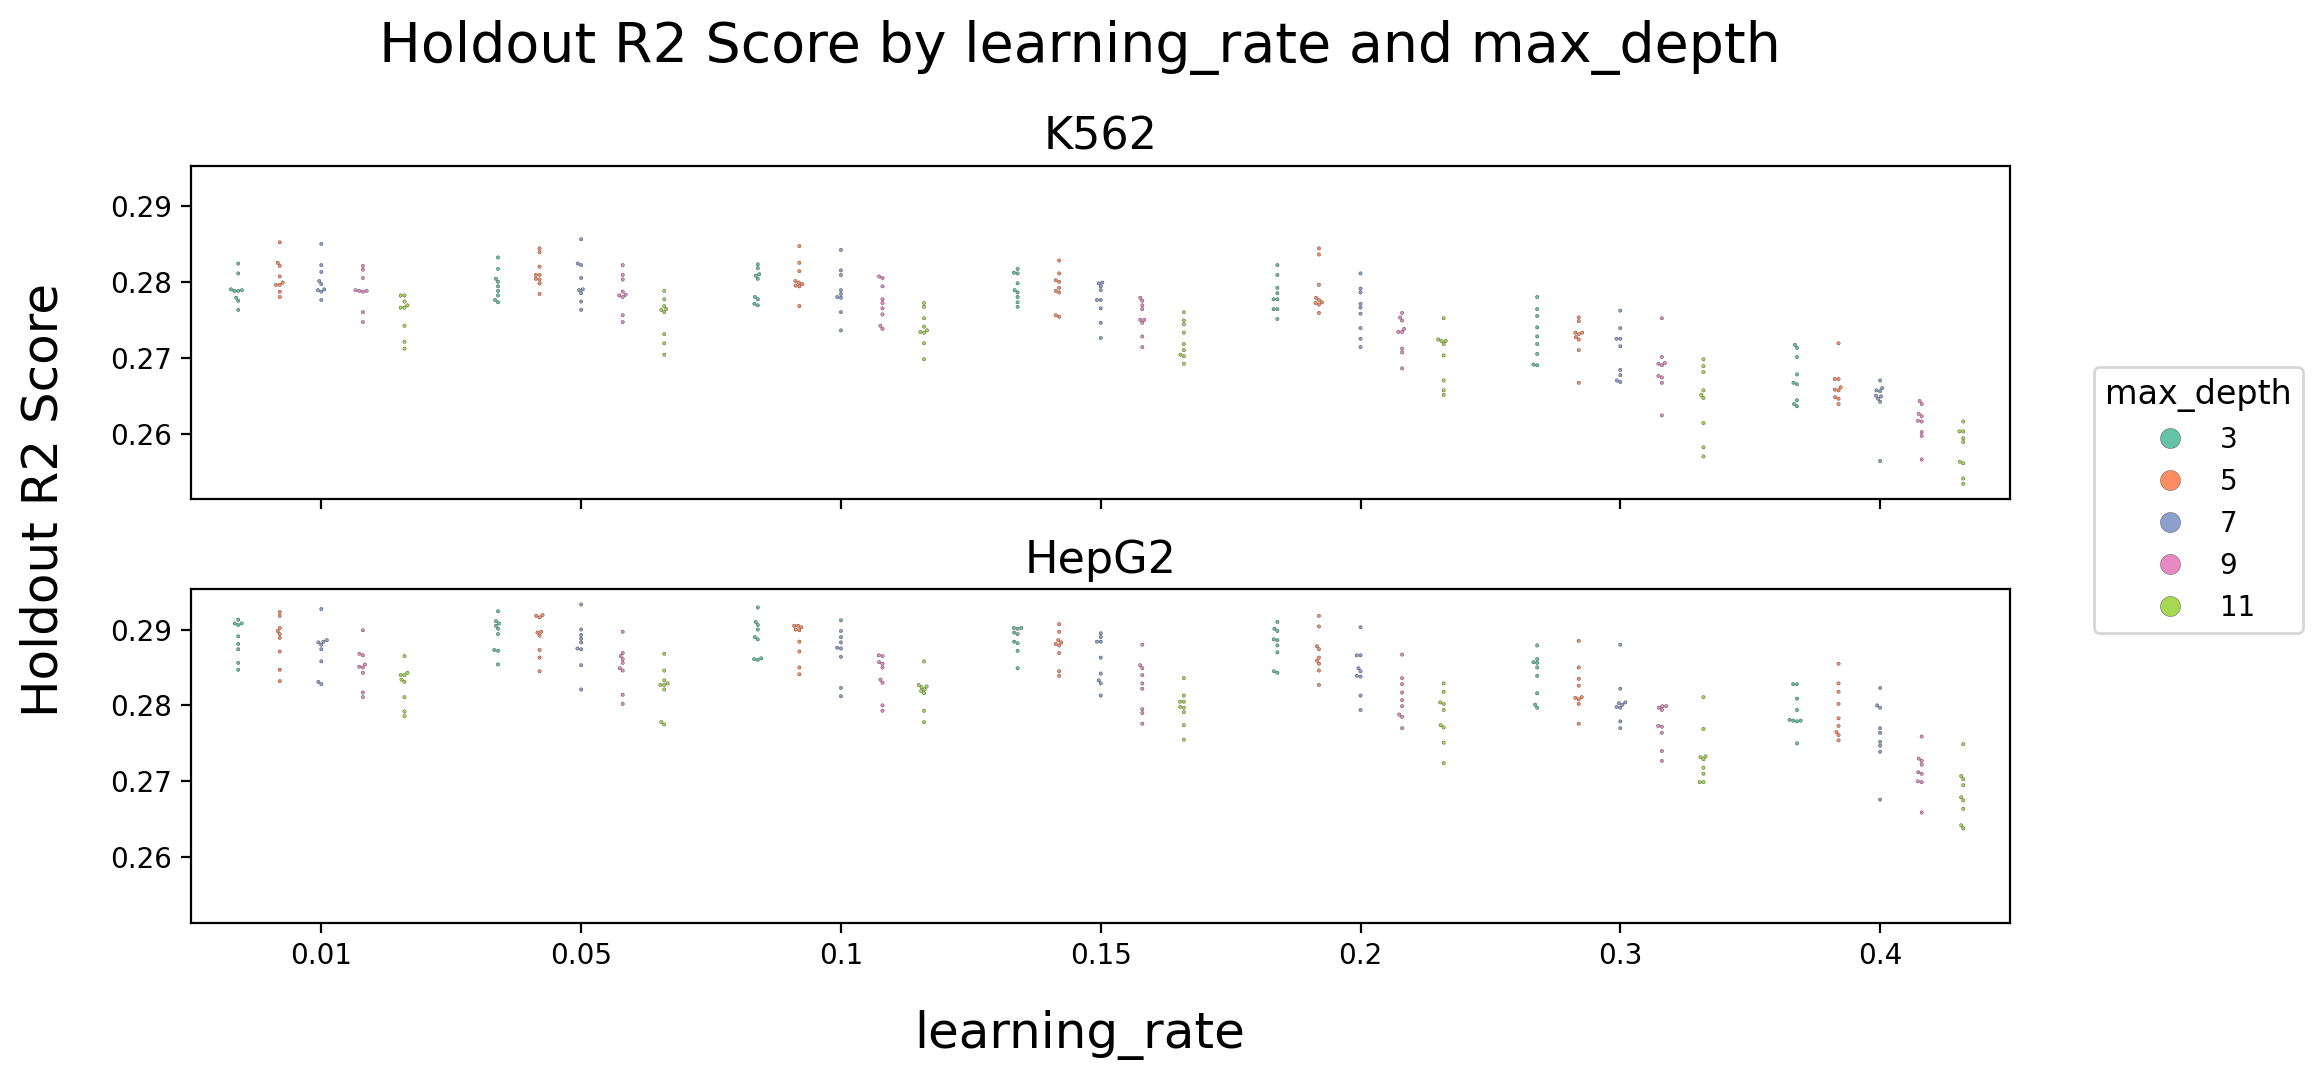

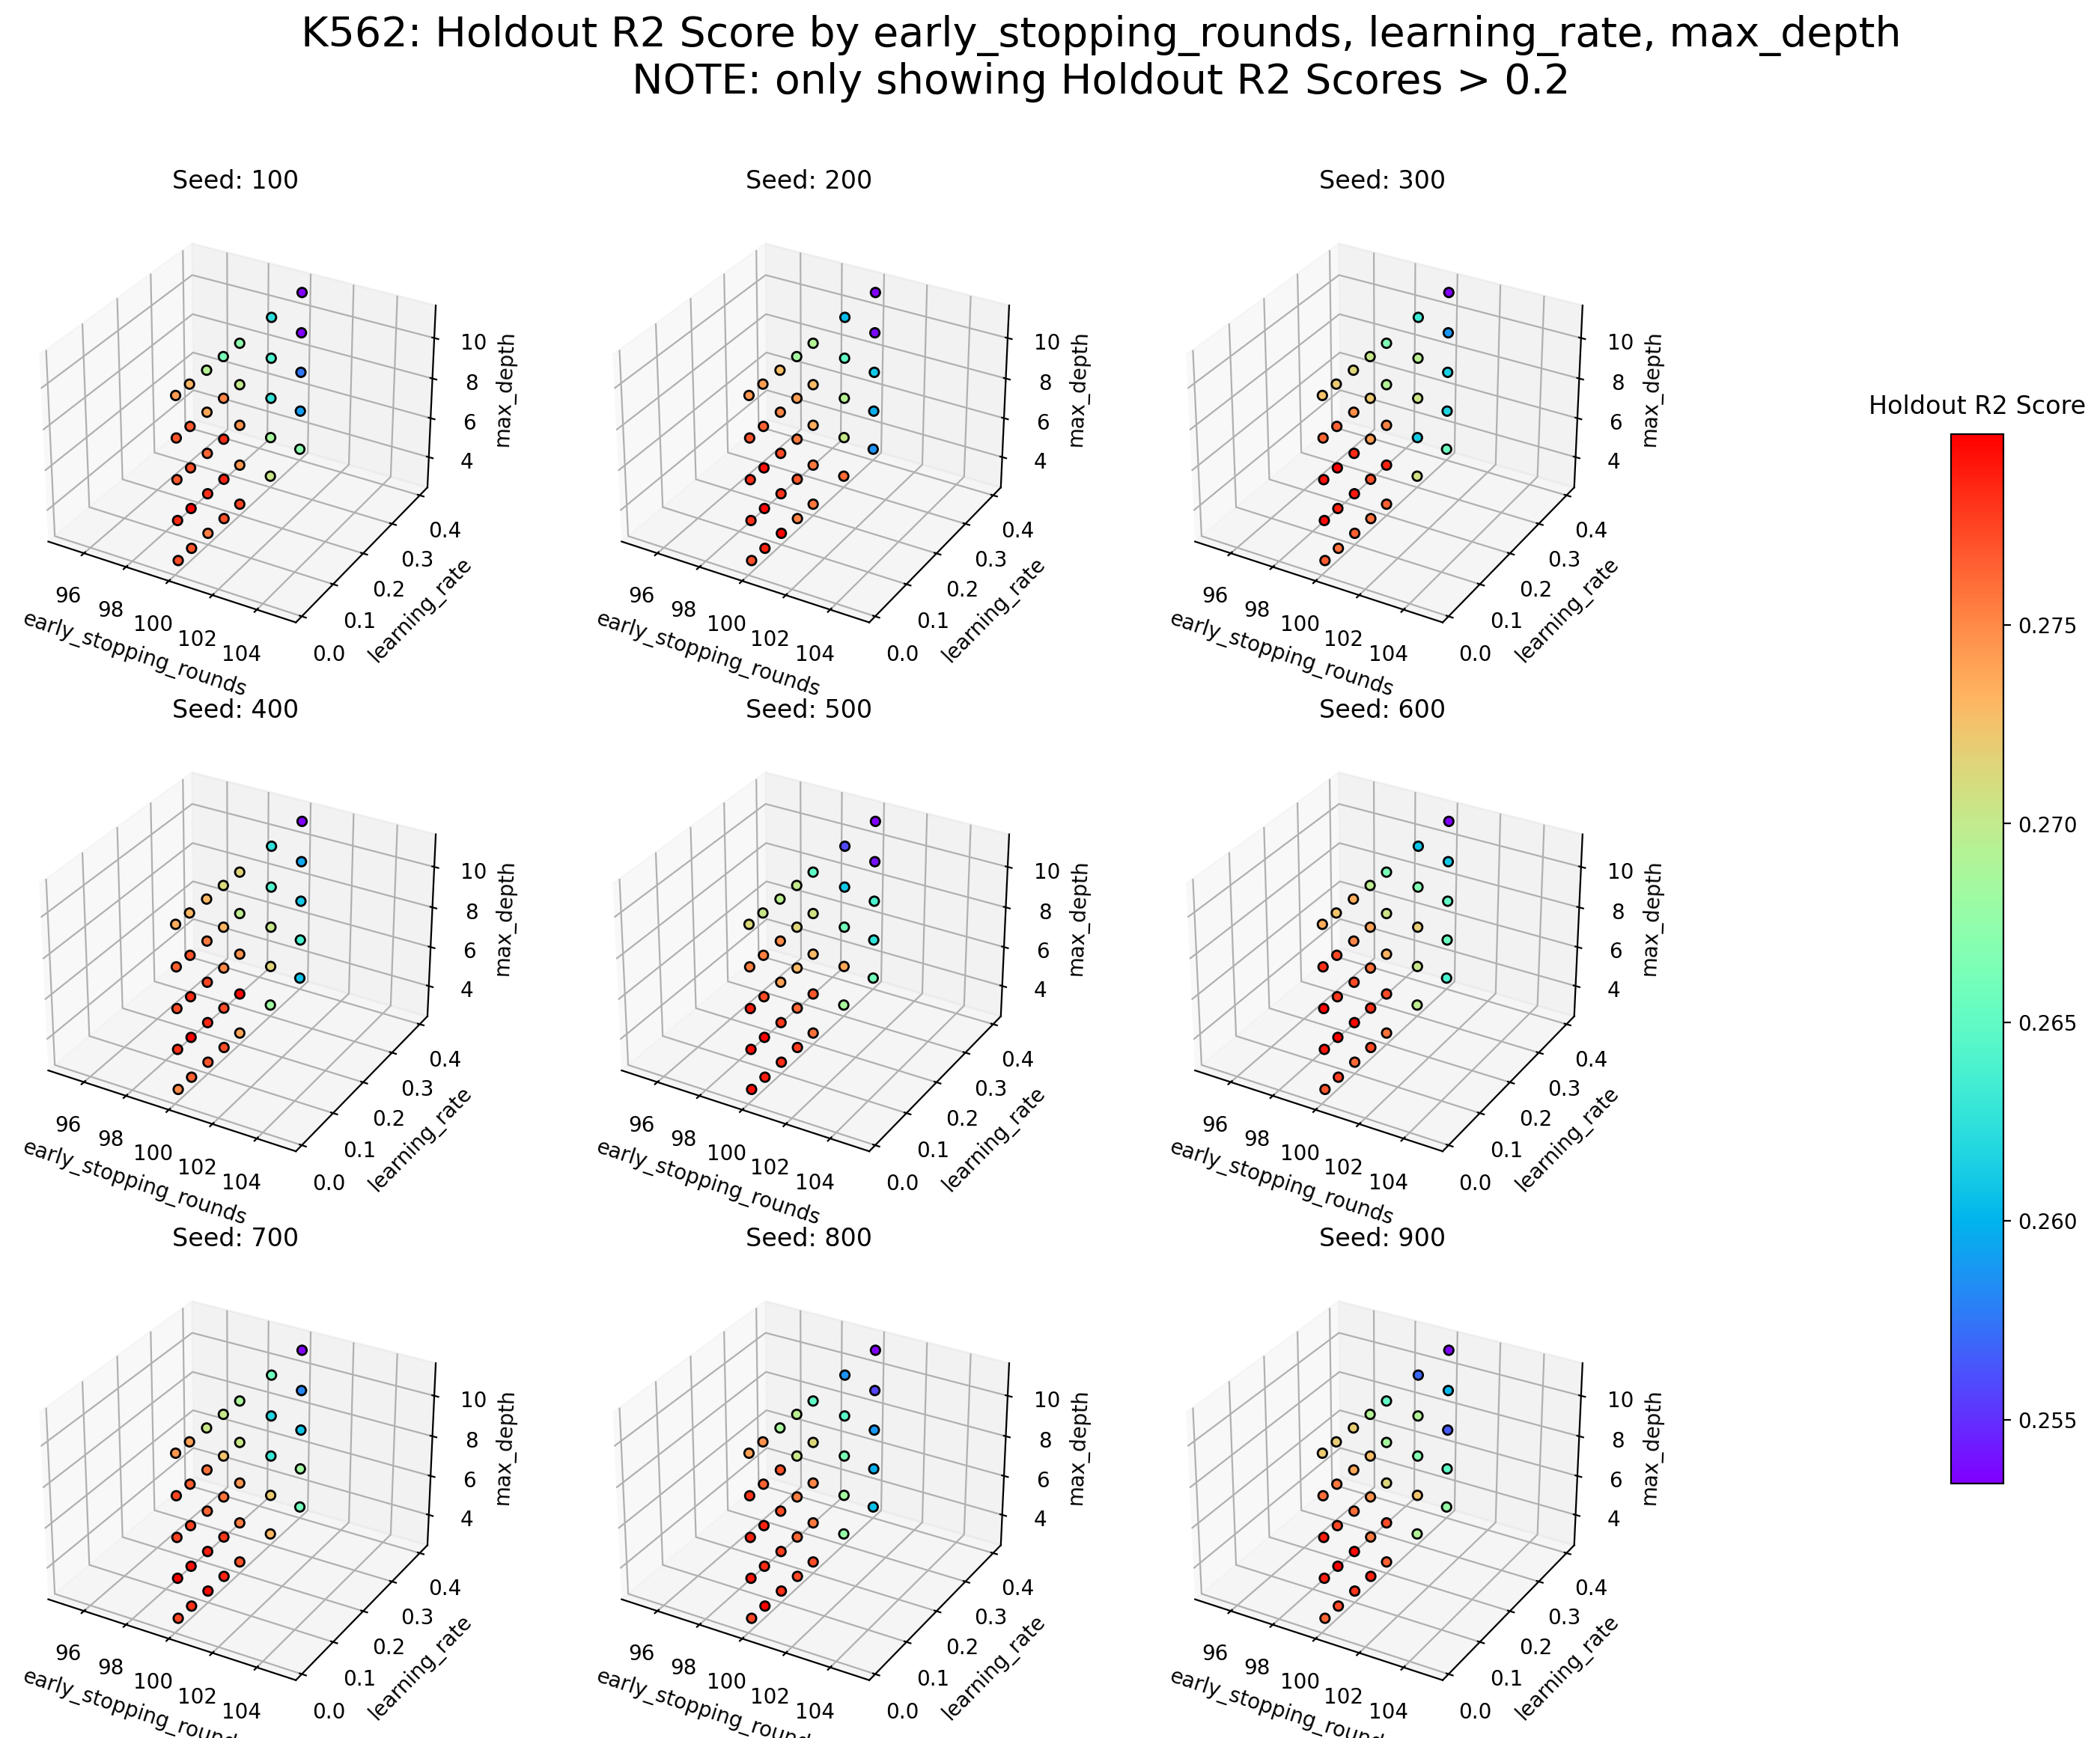

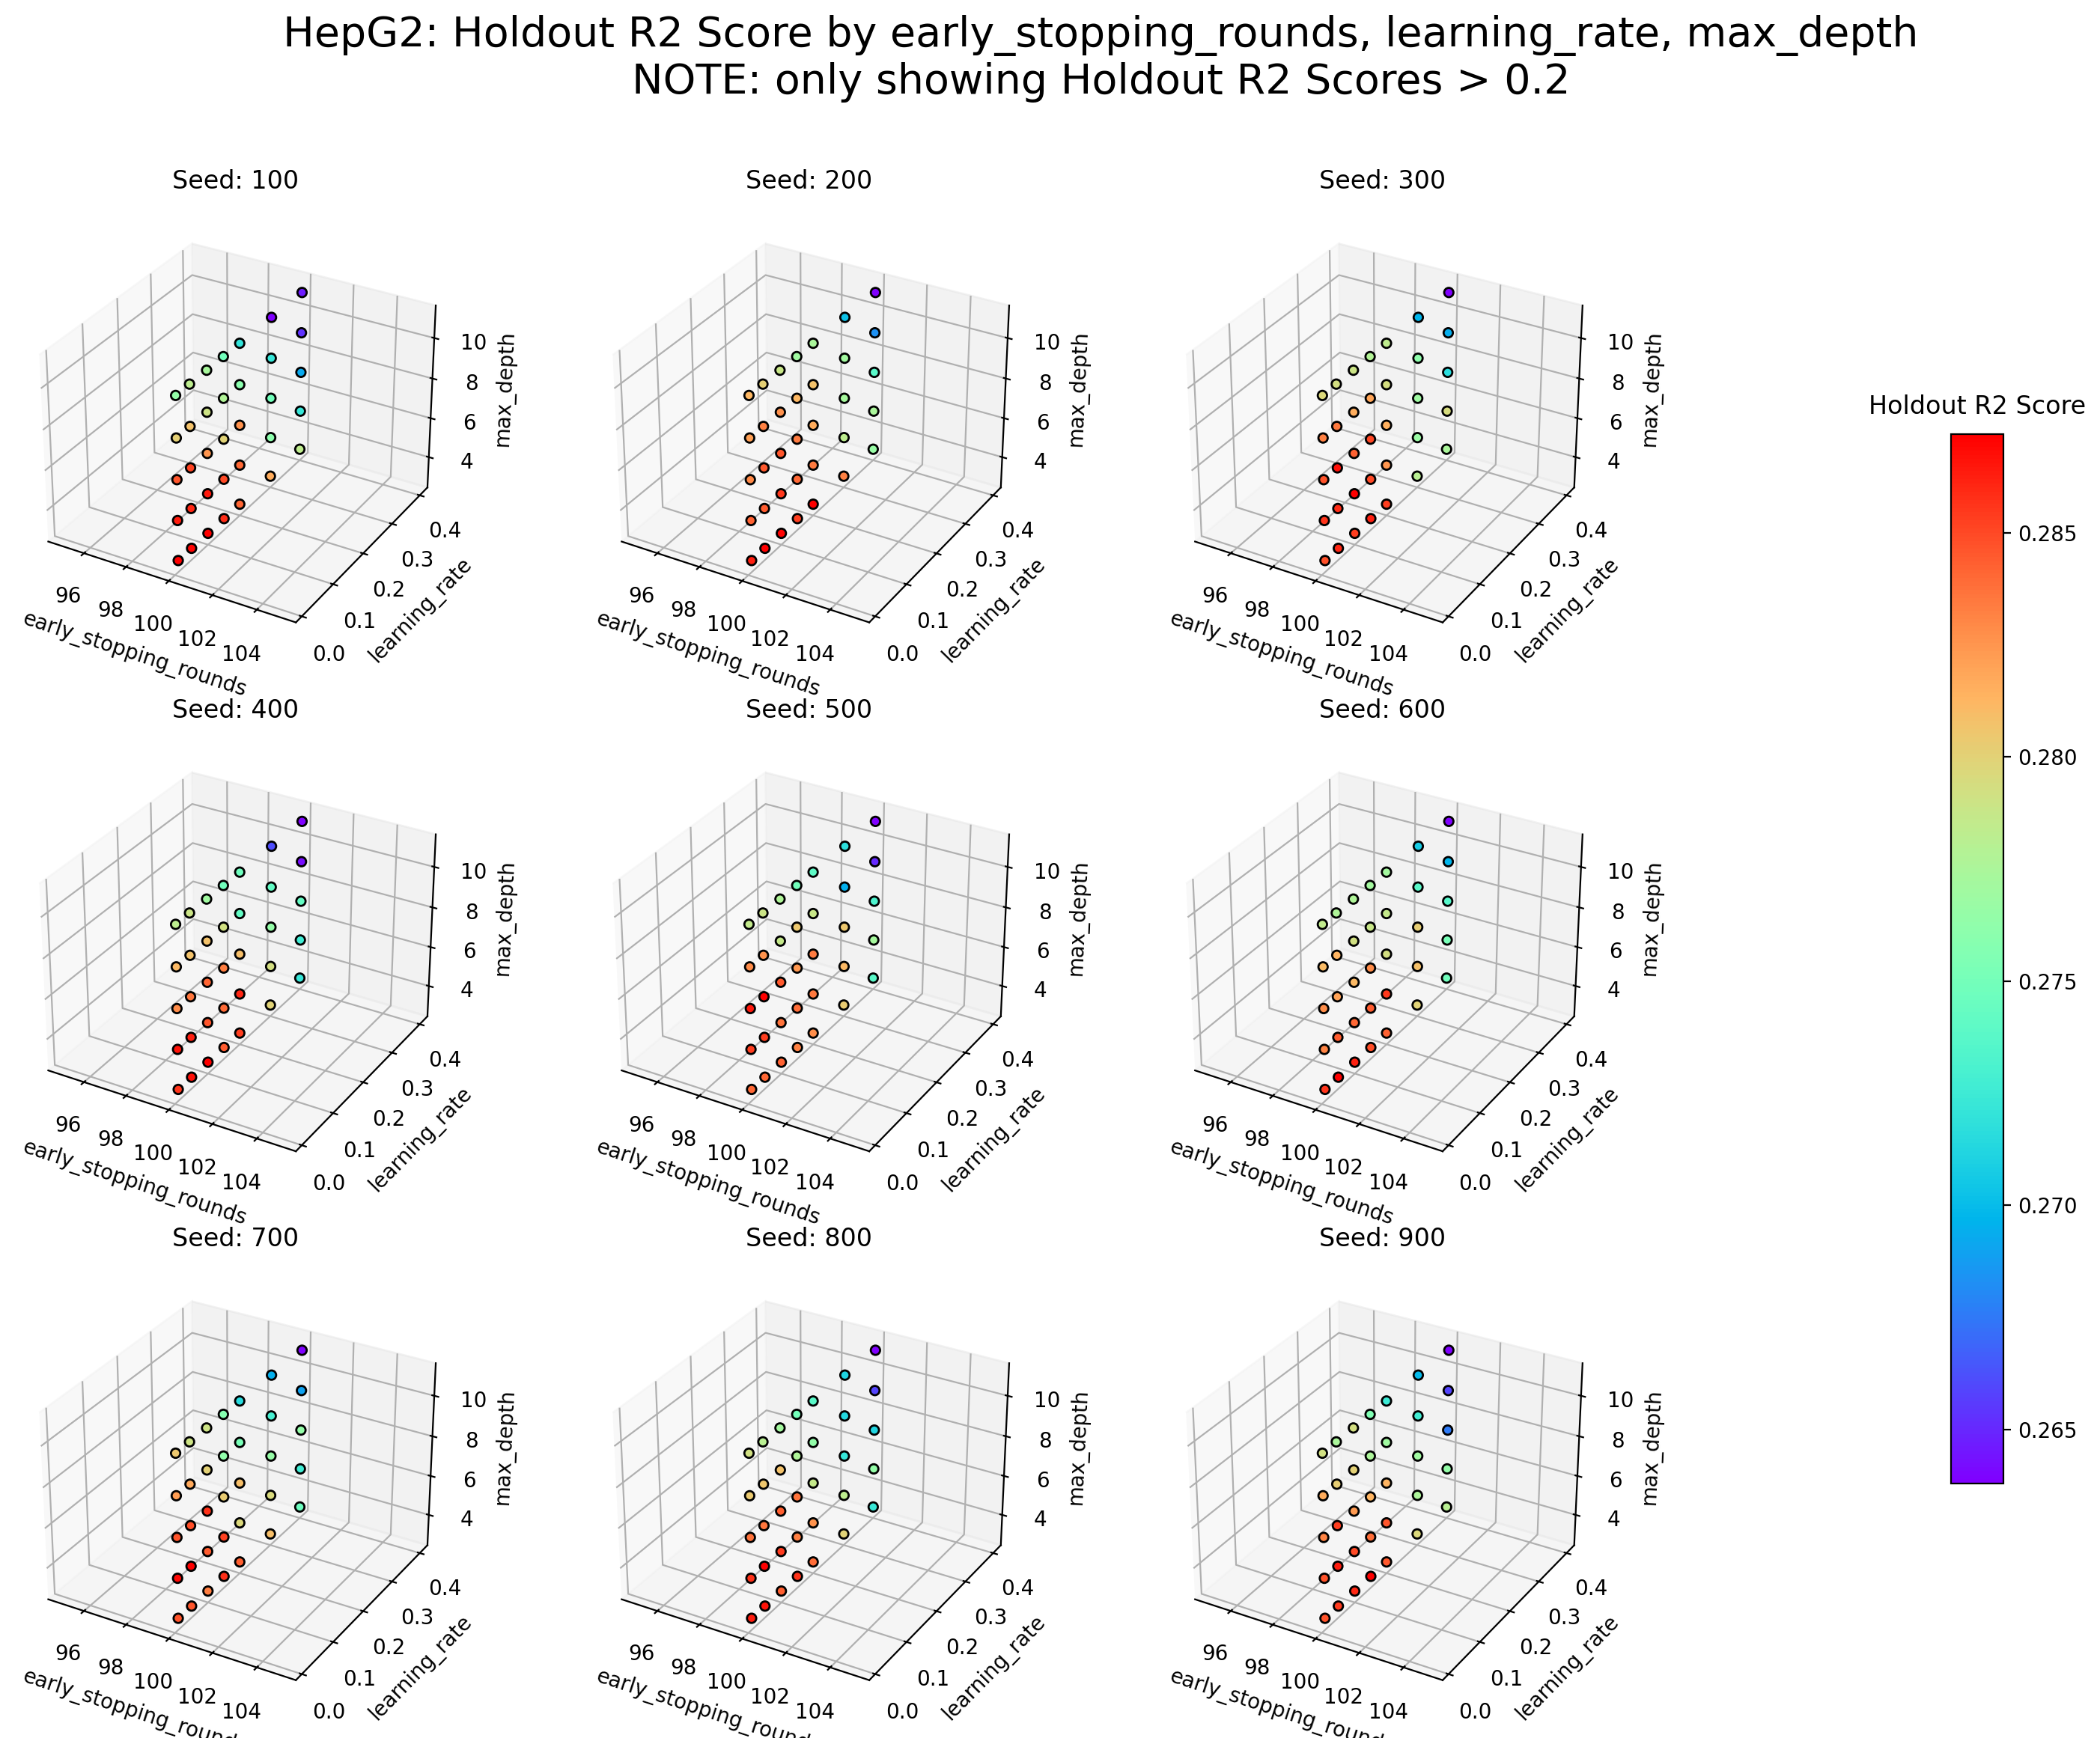

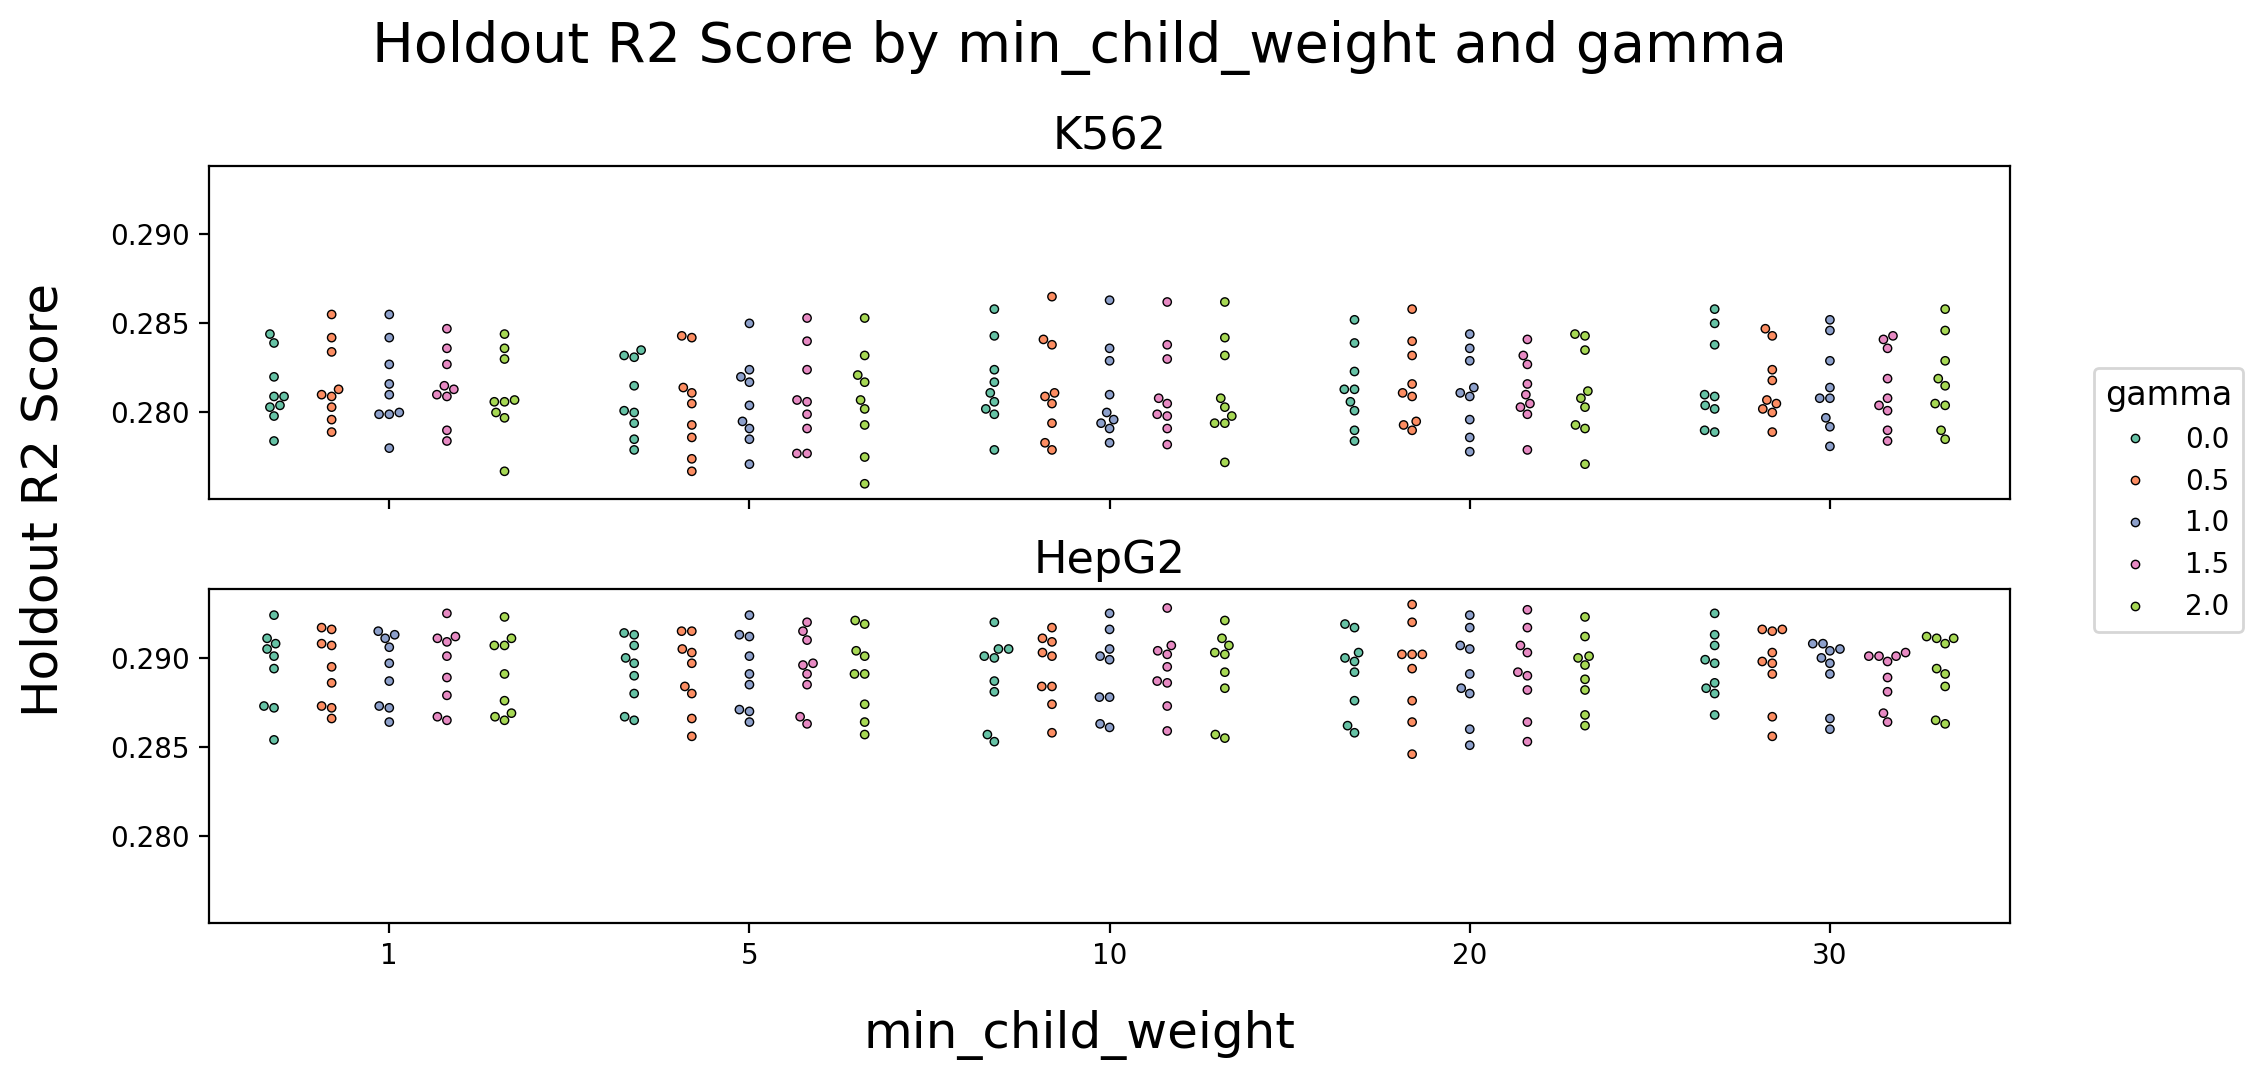

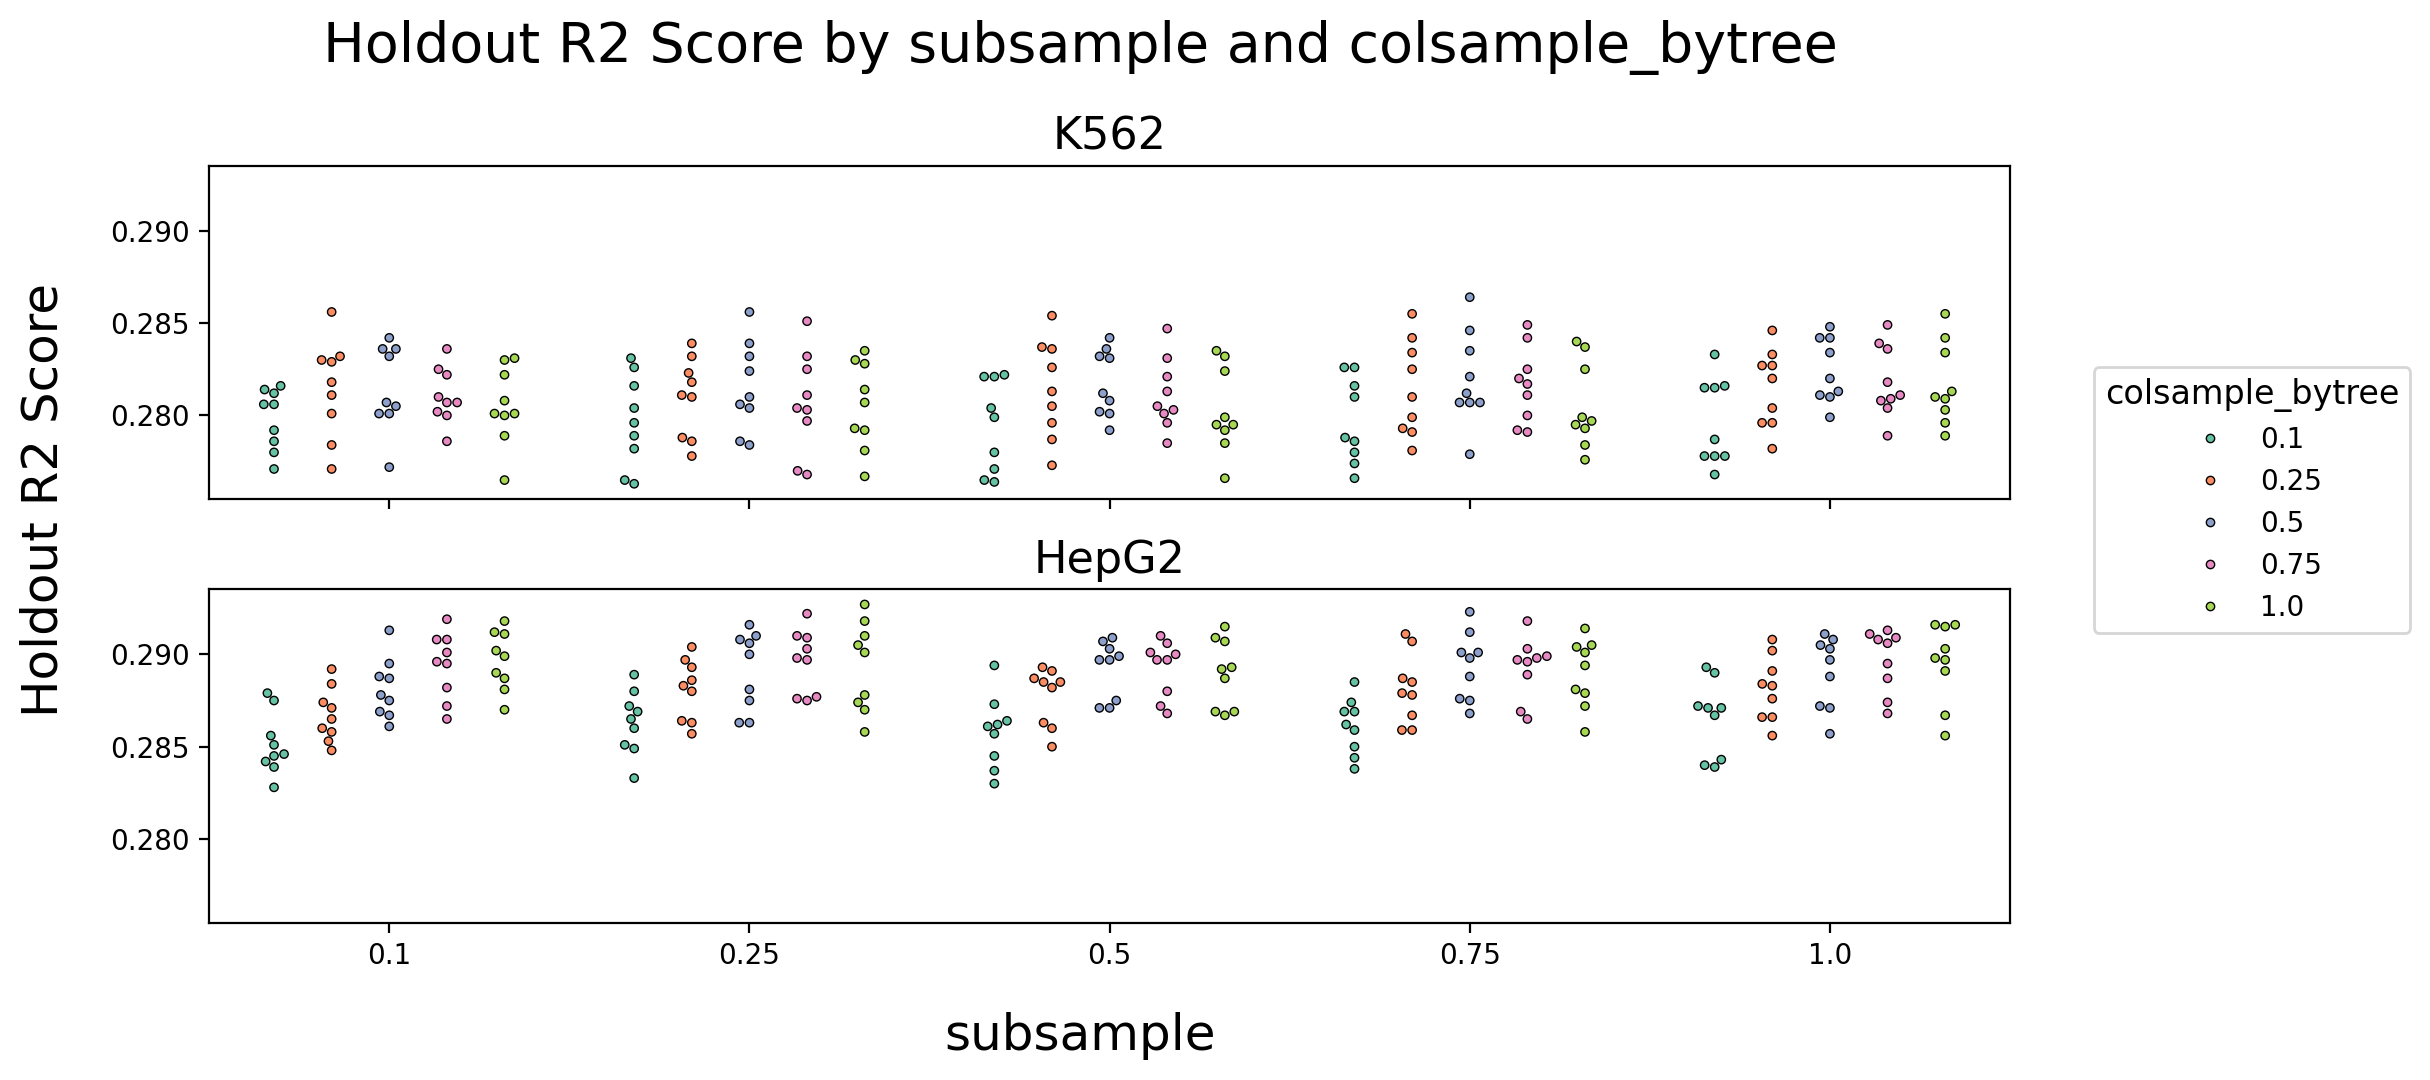

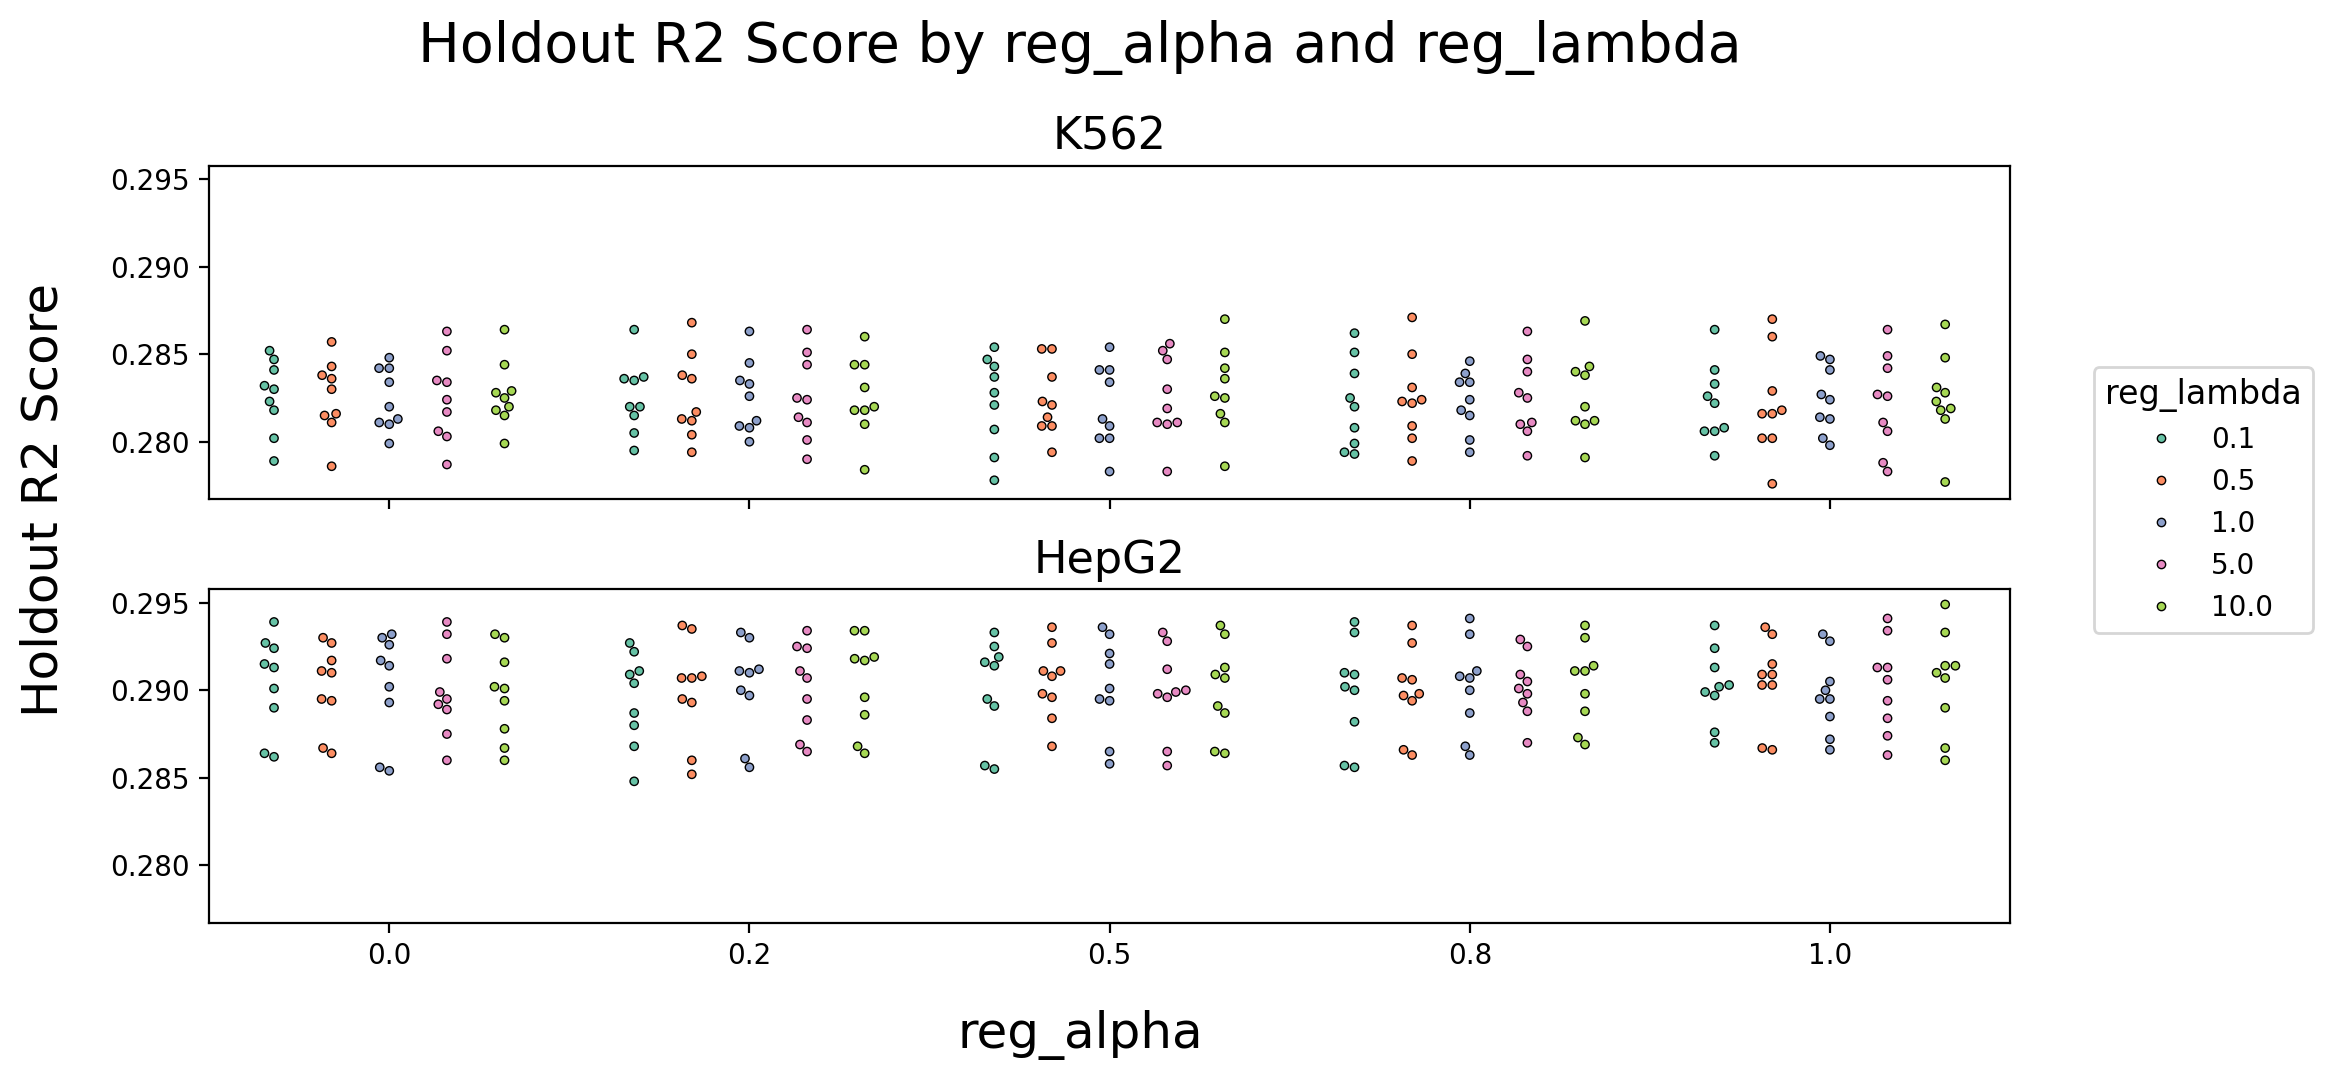

In [11]:
analyzer.plot_interrelated_model_hyperparameter_results_in_higher_dimensions()

## Choosing Top 5 Models After Averaging by Seed

In [13]:
analyzer.show_top_model_configs_after_averaging_by_seed(all_configs=True)

2025-04-08 11:09:23.866 | INFO     | dataset_and_model_parameter_chooser:show_top_model_configs_after_averaging_by_seed:245 - Model sweep shape: (1980, 56)
2025-04-08 11:09:23.872 | WARNING  | dataset_and_model_parameter_chooser:show_top_model_configs_after_averaging_by_seed:288 - Dropping model hyperparameter duplicates after all sweeps ran. 
Original shape: (1980, 56), new shape: (1935, 56)


,model.early_stopping_rounds,model.learning_rate,model.max_depth,model.min_child_weight,model.gamma,model.subsample,model.colsample_bytree,model.reg_alpha,model.reg_lambda,dataset.cell_line,avg_holdout_r2_score
0,100,0.05,5,1,0.5,1.0,0.75,1.0,10.0,HepG2,0.290489
1,100,0.05,5,1,0.5,1.0,0.75,1.0,0.5,HepG2,0.290444
2,100,0.05,5,1,0.5,1.0,0.75,0.5,0.5,HepG2,0.290433
3,100,0.05,5,1,0.5,1.0,0.75,0.2,10.0,HepG2,0.290400
4,100,0.05,5,1,0.5,1.0,0.75,0.0,0.1,HepG2,0.290389
5,100,0.05,5,1,0.5,1.0,0.75,0.8,10.0,HepG2,0.290344
6,100,0.05,5,1,0.5,1.0,0.75,0.0,1.0,HepG2,0.290267
7,100,0.05,5,1,0.5,1.0,0.75,1.0,5.0,HepG2,0.290244
8,100,0.05,5,1,0.5,1.0,0.75,1.0,0.1,HepG2,0.290233
9,100,0.05,5,1,0.5,1.0,0.75,0.8,5.0,HepG2,0.290200


<h1 style="color: teal; font-weight: bold; font-size: 48px;">Outer Loop Holdout R2 Scores</h1>

In [ ]:
run_ids = analyzer.get_run_ids_for_outer_loop_holdout_r2_scores()
run_ids

#### Run the following commands: 

* `source /scratch/jve4pt/platiglib/platiglib_venv/bin/activate`
* `python ./6_run_outer_loop_holdout_r2.py`

In [ ]:
analyzer.assert_outer_loop_holdout_r2_scores()

In [ ]:
analyzer.inner_fold_vs_outer_fold_r2_score_table()

In [ ]:
analyzer.save_hyperparameters_for_final_modeling()

In [ ]:
# analyzer.plot_outer_loop_fold_r2_score_results()